In [2]:
from pathlib import Path
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() in ["notebooks"]:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
TD = pd.read_csv(PROJECT_ROOT / "data" / "summary_table_quasars.csv")
PROBA = pd.read_csv(PROJECT_ROOT / "data" / "nnet_pair_predictions.csv")
REDSHIFT = pd.read_csv(PROJECT_ROOT / "data" / "redshift_True.csv")
Full = pd.read_csv(PROJECT_ROOT / "data" / "BigEOL.csv")

In [4]:
REDSHIFT[REDSHIFT["SIdComp"] == 5294172436481530437]

,sourceId_1,SIdComp,gravLensName,nOutliers,minDist,maxDist,minG,maxG,nValidObs,minNObs,...,redShiftalt_qsoc_lower,redShiftalt_qsoc_upper,redShiftalt_qsoc_prob,redShiftalt_qsoc_logprob,gmag_qsoc,gmag_qsoc_lower,gmag_qsoc_upper,ccfratio_qsoc,zscore_qsoc,flags_qsoc
181260,5294172436481530368,5294172436481530437,DR4Gaia075825.814-585210.46,17,4.926835,7.774717,20.213275,20.625735,153,38,...,1.889724,1.969425,0.241863,1.43364,-25.040049,-25.045622,-25.034475,0.999581,0.132131,2077


In [6]:
# Voir toutes les colonnes sans troncature
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)

for name, df_ in {
    "TD": TD,
    "PROBA": PROBA,
    "REDSHIFT": REDSHIFT,
    "Full": Full,
}.items():
    print("\n" + "="*80)
    print(name)
    print("="*80)
    print("shape:", df_.shape)
    print("columns:")
    print(list(df_.columns))


TD
shape: (38331, 62)
columns:
['Source_Id', 'Source_Id_1', 'Source_Id_2', 'Source_Id_1_Source_Id_2', 'N_brut_1', 'n1', 'n_exclus_1', 'nn1', 'ave_Flux_1', 'sig_Flux_1', 'N_brut_2', 'n2', 'n_exclus_2', 'nn2', 'ave_Flux_2', 'sig_Flux_2', 'TD_eqm', 'eqm_min', 'eqm_overlap', 'TD_eqmd1i2', 'eqm_mind1i2', 'eqm_overlapd1i2', 'TD_eqmi1d2', 'eqm_mini1d2', 'eqm_overlapi1d2', 'TD_cor', 'cor_max', 'cor_overlap', 'TD_cord1i2', 'cor_maxd1i2', 'cor_overlapd1i2', 'TD_cori1d2', 'cor_maxi1d2', 'cor_overlapi1d2', 'TD_cor_eqm', 'cor_eqm_max', 'cor_eqm_overlap', 'TD_cor_eqmd1i2', 'cor_eqm_maxd1i2', 'cor_eqm_overlapd1i2', 'TD_cor_eqmi1d2', 'cor_eqm_maxi1d2', 'cor_eqm_overlapi1d2', 'TD_rbf', 'rbf_min', 'rbf_overlap', 'TD_bspl3', 'n_bspl3', 'bspl3_min', 'bspl3_overlap', 'TD_bspl5', 'n_bspl5', 'bspl5_min', 'bspl5_overlap', 'TD_bspl8', 'n_bspl8', 'bspl8_min', 'bspl8_overlap', 'Moyenne_Non_Ponderee', 'EcartType_Non_Pondere', 'Mediane_Simple', 'Est_Eligible']

PROBA
shape: (22557, 4)
columns:
['sourceID', 'compA

In [13]:
import numpy as np
import pandas as pd

from scipy.spatial import cKDTree


# ============================================================
# Load files safely
# ============================================================

def read_csv_clean(path):
    df = pd.read_csv(path)
    df.columns = df.columns.astype(str).str.strip()

    unnamed = [c for c in df.columns if c.startswith("Unnamed")]
    if len(unnamed) > 0:
        df = df.drop(columns=unnamed)

    return df


TD = read_csv_clean(PROJECT_ROOT / "data" / "summary_table_quasars.csv")
PROBA = read_csv_clean(PROJECT_ROOT / "data" / "nnet_pair_predictions.csv")
REDSHIFT = read_csv_clean(PROJECT_ROOT / "data" / "redshift_True.csv")
Full = read_csv_clean(PROJECT_ROOT / "data" / "BigEOL.csv")
LC = read_csv_clean(PROJECT_ROOT / "data" / "cleaned_lightcurves.csv")

KNOWN_LC_PATH = PROJECT_ROOT / "data" / "dgdreq2025nov21_JB.csv"
KNOWN_LC = read_csv_clean(KNOWN_LC_PATH)


# ============================================================
# Small tools
# ============================================================

def to_id(s):
    return pd.to_numeric(s, errors="coerce").astype("Int64")


def pair_key(a, b):
    a = to_id(a)
    b = to_id(b)

    lo = pd.concat([a, b], axis=1).min(axis=1).astype("Int64").astype(str)
    hi = pd.concat([a, b], axis=1).max(axis=1).astype("Int64").astype(str)

    return lo + "_" + hi


def keep_existing(df, cols):
    return [c for c in cols if c in df.columns]


def keep_existing_unique(df, cols):
    out = []
    seen = set()

    for c in cols:
        if c in df.columns and c not in seen:
            out.append(c)
            seen.add(c)

    return out


def angular_sep_arcsec(ra1, dec1, ra2, dec2):
    ra1 = np.deg2rad(pd.to_numeric(ra1, errors="coerce"))
    dec1 = np.deg2rad(pd.to_numeric(dec1, errors="coerce"))
    ra2 = np.deg2rad(pd.to_numeric(ra2, errors="coerce"))
    dec2 = np.deg2rad(pd.to_numeric(dec2, errors="coerce"))

    dra = ra2 - ra1
    ddec = dec2 - dec1

    a = (
        np.sin(ddec / 2) ** 2
        + np.cos(dec1) * np.cos(dec2) * np.sin(dra / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return np.rad2deg(c) * 3600.0


def radec_to_xyz(ra_deg, dec_deg):
    ra = np.deg2rad(pd.to_numeric(ra_deg, errors="coerce").to_numpy(float))
    dec = np.deg2rad(pd.to_numeric(dec_deg, errors="coerce").to_numpy(float))

    x = np.cos(dec) * np.cos(ra)
    y = np.cos(dec) * np.sin(ra)
    z = np.sin(dec)

    return np.vstack([x, y, z]).T


def arcsec_to_chord(arcsec):
    angle_rad = np.deg2rad(arcsec / 3600.0)
    return 2 * np.sin(angle_rad / 2)


def chord_to_arcsec(chord):
    chord = np.asarray(chord, float)
    chord = np.clip(chord, 0, 2)

    angle_rad = 2 * np.arcsin(chord / 2)

    return np.rad2deg(angle_rad) * 3600.0


def nearest_known_radec(query_ra, query_dec, known_pos, radius_arcsec=2.0):
    out = pd.DataFrame(index=np.arange(len(query_ra)))

    out["nearest_known_sep_arcsec"] = np.nan
    out["nearest_known_comp_id"] = pd.Series([pd.NA] * len(query_ra), dtype="Int64")
    out["nearest_known_source_id"] = pd.Series([pd.NA] * len(query_ra), dtype="Int64")
    out["known_radec_match"] = False

    valid_known = known_pos.dropna(subset=["known_ra", "known_dec"]).copy()

    if len(valid_known) == 0:
        return out

    known_xyz = radec_to_xyz(valid_known["known_ra"], valid_known["known_dec"])
    tree = cKDTree(known_xyz)

    query = pd.DataFrame({
        "ra": query_ra,
        "dec": query_dec,
    })

    valid_query = query.dropna(subset=["ra", "dec"]).copy()

    if len(valid_query) == 0:
        return out

    query_xyz = radec_to_xyz(valid_query["ra"], valid_query["dec"])

    max_chord = arcsec_to_chord(radius_arcsec)

    dist, idx = tree.query(
        query_xyz,
        k=1,
        distance_upper_bound=max_chord,
    )

    matched = np.isfinite(dist) & (idx < len(valid_known))

    valid_indices = valid_query.index.to_numpy()

    matched_query_idx = valid_indices[matched]
    matched_known_idx = idx[matched]

    out.loc[matched_query_idx, "nearest_known_sep_arcsec"] = chord_to_arcsec(dist[matched])

    out.loc[matched_query_idx, "nearest_known_comp_id"] = (
        valid_known.iloc[matched_known_idx]["known_comp_id_from_full"]
        .astype("Int64")
        .to_numpy()
    )

    out.loc[matched_query_idx, "nearest_known_source_id"] = (
        valid_known.iloc[matched_known_idx]["known_source_id_from_full"]
        .astype("Int64")
        .to_numpy()
    )

    out.loc[matched_query_idx, "known_radec_match"] = True

    return out


# ============================================================
# Redshift matching tools
# ============================================================

def add_redshift_match_columns(df):
    df = df.copy()

    pairs = {
        "primary_primary": ("redshift_qsoc_1", "redshift_qsoc_2"),
        "primary_alt": ("redshift_qsoc_1", "redShiftalt_qsoc_2"),
        "alt_primary": ("redShiftalt_qsoc_1", "redshift_qsoc_2"),
        "alt_alt": ("redShiftalt_qsoc_1", "redShiftalt_qsoc_2"),
    }

    diff_cols = []

    for name, (c1, c2) in pairs.items():
        out = f"z_diff_{name}"

        if c1 in df.columns and c2 in df.columns:
            df[out] = np.abs(
                pd.to_numeric(df[c1], errors="coerce")
                - pd.to_numeric(df[c2], errors="coerce")
            )
        else:
            df[out] = np.nan

        diff_cols.append(out)

    df["redshift_min_abs_diff"] = df[diff_cols].min(axis=1, skipna=True)

    arr = df[diff_cols].to_numpy(float)
    all_nan = np.all(~np.isfinite(arr), axis=1)

    idx = np.nanargmin(
        np.where(np.isfinite(arr), arr, np.inf),
        axis=1,
    )

    names = np.array([
        "primary_primary",
        "primary_alt",
        "alt_primary",
        "alt_alt",
    ])

    df["redshift_best_combo"] = names[idx]
    df.loc[all_nan, "redshift_best_combo"] = np.nan

    df["redshift_match_0p01"] = df["redshift_min_abs_diff"] <= 0.01
    df["redshift_match_0p05"] = df["redshift_min_abs_diff"] <= 0.05
    df["redshift_match_0p10"] = df["redshift_min_abs_diff"] <= 0.10

    return df


# ============================================================
# Diagnostics columns
# ============================================================

print("TD columns:", list(TD.columns[:10]))
print("PROBA columns:", list(PROBA.columns))
print("REDSHIFT columns:", list(REDSHIFT.columns[:10]))
print("Full columns:", list(Full.columns[:10]))
print("LC columns:", list(LC.columns[:10]))
print("KNOWN_LC columns:", list(KNOWN_LC.columns[:10]))


# ============================================================
# Known lens IDs from known light-curve file
# ============================================================

KNOWN_LC["known_source_id"] = to_id(KNOWN_LC["source_id"])
KNOWN_LC["known_comp_id"] = to_id(KNOWN_LC["lensComponentSourceId"])

known_source_ids = set(
    KNOWN_LC["known_source_id"]
    .dropna()
    .astype("int64")
    .tolist()
)

known_comp_ids = set(
    KNOWN_LC["known_comp_id"]
    .dropna()
    .astype("int64")
    .tolist()
)

known_systems = (
    KNOWN_LC[["known_source_id", "known_comp_id"]]
    .dropna()
    .drop_duplicates()
    .copy()
)

print("\nKnown LC shape:", KNOWN_LC.shape)
print("Known source IDs:", len(known_source_ids))
print("Known component IDs:", len(known_comp_ids))


# ============================================================
# TD base table
# ============================================================

td_id_cols = [
    "Source_Id",
    "Source_Id_1",
    "Source_Id_2",
]

flux_cols = [
    "ave_Flux_1",
    "sig_Flux_1",
    "ave_Flux_2",
    "sig_Flux_2",
]

td_stat_cols = [
    c for c in TD.columns
    if (
        c.startswith("TD_eqm")
        or c.startswith("eqm_")
        or c.startswith("TD_cor")
        or c.startswith("cor_")
    )
    and ("rbf" not in c.lower())
    and ("bspl" not in c.lower())
]

td_keep = keep_existing(TD, td_id_cols + flux_cols + td_stat_cols)

missing_td = [c for c in td_id_cols if c not in TD.columns]

if len(missing_td) > 0:
    raise ValueError(f"Colonnes manquantes dans TD : {missing_td}")

base = TD[td_keep].copy()

base["source_id"] = to_id(base["Source_Id"])
base["comp1_id"] = to_id(base["Source_Id_1"])
base["comp2_id"] = to_id(base["Source_Id_2"])
base["pair_key"] = pair_key(base["comp1_id"], base["comp2_id"])


# ============================================================
# Known exact ID match
# ============================================================

base["Known_source_id_match"] = base["source_id"].isin(known_source_ids)
base["Known_comp1_id_match"] = base["comp1_id"].isin(known_comp_ids)
base["Known_comp2_id_match"] = base["comp2_id"].isin(known_comp_ids)

base["Known_id_match"] = (
    base["Known_source_id_match"]
    | base["Known_comp1_id_match"]
    | base["Known_comp2_id_match"]
)


# ============================================================
# PROBA merge
# ============================================================

proba = PROBA.copy()

proba["source_id"] = to_id(proba["sourceID"])
proba["compA_id"] = to_id(proba["compA"])
proba["compB_id"] = to_id(proba["compB"])
proba["pair_key"] = pair_key(proba["compA_id"], proba["compB_id"])

proba = proba[["source_id", "pair_key", "Proba"]].drop_duplicates(
    ["source_id", "pair_key"]
)

base = base.merge(
    proba,
    on=["source_id", "pair_key"],
    how="left",
)


# ============================================================
# Gaia lightcurve error stats
# ============================================================

lc = LC.copy()

lc["comp_id"] = to_id(lc["lensComponentSourceId"])

err = (
    lc.groupby("comp_id", as_index=False)
    .agg(
        ave_error_flux=("flux_obs_error", "mean"),
        med_error_flux=("flux_obs_error", "median"),
        std_error_flux=("flux_obs_error", "std"),
        n_flux_points=("flux_obs_error", "size"),
    )
)

err1 = err.add_suffix("_1").rename(columns={"comp_id_1": "comp1_id"})
err2 = err.add_suffix("_2").rename(columns={"comp_id_2": "comp2_id"})

base = base.merge(err1, on="comp1_id", how="left")
base = base.merge(err2, on="comp2_id", how="left")


# ============================================================
# Astrometry / photometry from Full
# ============================================================

full = Full.copy()

if "SIdComp" in full.columns:
    full["comp_id"] = to_id(full["SIdComp"])
elif "componentId" in full.columns:
    full["comp_id"] = to_id(full["componentId"])
else:
    raise ValueError("Impossible de trouver l'identifiant composante dans Full.")

full_cols = [
    "comp_id",
    "sourceId",
    "SIdComp",
    "componentId",
    "raComp",
    "stdRaComp",
    "decComp",
    "stdDecComp",
    "GComp",
    "stdGComp",
    "vpuGMagComp",
    "stdVpuGMagComp",
    "minG",
    "maxG",
    "nObsComp",
    "matchedSourceIdDR4",
    "matchedDistance",
]

full_cols = keep_existing(full, full_cols)

full_comp = full[full_cols].copy()

if "nObsComp" in full_comp.columns:
    full_comp = (
        full_comp
        .sort_values(["comp_id", "nObsComp"], ascending=[True, False])
        .drop_duplicates("comp_id")
    )
else:
    full_comp = full_comp.drop_duplicates("comp_id")

if "GComp" in full_comp.columns and "vpuGMagComp" in full_comp.columns:
    full_comp["G_minus_vpuG"] = full_comp["GComp"] - full_comp["vpuGMagComp"]

full1 = full_comp.add_suffix("_1").rename(columns={"comp_id_1": "comp1_id"})
full2 = full_comp.add_suffix("_2").rename(columns={"comp_id_2": "comp2_id"})

base = base.merge(full1, on="comp1_id", how="left")
base = base.merge(full2, on="comp2_id", how="left")


# ============================================================
# Separation in arcsec between comp1 and comp2
# ============================================================

base["separation_arcsec"] = angular_sep_arcsec(
    base["raComp_1"],
    base["decComp_1"],
    base["raComp_2"],
    base["decComp_2"],
)


# ============================================================
# Known RA/DEC table from Full
# ============================================================

known_pos = full_comp[
    full_comp["comp_id"].isin(list(known_comp_ids))
].copy()

known_pos = known_pos.dropna(subset=["raComp", "decComp"])

known_pos = known_pos.rename(columns={
    "comp_id": "known_comp_id_from_full",
    "sourceId": "known_source_id_from_full",
    "raComp": "known_ra",
    "decComp": "known_dec",
})

known_pos_cols = [
    "known_comp_id_from_full",
    "known_source_id_from_full",
    "known_ra",
    "known_dec",
]

known_pos_cols = keep_existing(known_pos, known_pos_cols)

known_pos = (
    known_pos[known_pos_cols]
    .drop_duplicates("known_comp_id_from_full")
    .copy()
)

print("\nKnown positions found in Full:", len(known_pos), "/", len(known_comp_ids))


# ============================================================
# Apply RA/DEC known matching to comp1 and comp2
# ============================================================

KNOWN_RADEC_RADIUS_ARCSEC = 2.0

known_match_1 = nearest_known_radec(
    base["raComp_1"],
    base["decComp_1"],
    known_pos,
    radius_arcsec=KNOWN_RADEC_RADIUS_ARCSEC,
)

known_match_2 = nearest_known_radec(
    base["raComp_2"],
    base["decComp_2"],
    known_pos,
    radius_arcsec=KNOWN_RADEC_RADIUS_ARCSEC,
)

base["known_nearest_sep_arcsec_1"] = known_match_1["nearest_known_sep_arcsec"]
base["known_nearest_comp_id_1"] = known_match_1["nearest_known_comp_id"]
base["known_nearest_source_id_1"] = known_match_1["nearest_known_source_id"]
base["Known_radec_match_1"] = known_match_1["known_radec_match"]

base["known_nearest_sep_arcsec_2"] = known_match_2["nearest_known_sep_arcsec"]
base["known_nearest_comp_id_2"] = known_match_2["nearest_known_comp_id"]
base["known_nearest_source_id_2"] = known_match_2["nearest_known_source_id"]
base["Known_radec_match_2"] = known_match_2["known_radec_match"]

base["Known_ra_dec_match"] = (
    base["Known_radec_match_1"]
    | base["Known_radec_match_2"]
)

base["Known"] = (
    base["Known_id_match"]
    | base["Known_ra_dec_match"]
)

base["Known_match_type"] = "none"

base.loc[
    base["Known_id_match"] & ~base["Known_ra_dec_match"],
    "Known_match_type",
] = "id_only"

base.loc[
    ~base["Known_id_match"] & base["Known_ra_dec_match"],
    "Known_match_type",
] = "radec_only"

base.loc[
    base["Known_id_match"] & base["Known_ra_dec_match"],
    "Known_match_type",
] = "id_and_radec"


# ============================================================
# Redshift primary / secondary for both components
# ============================================================

red = REDSHIFT.copy()

if "component_source_id" in red.columns:
    red["comp_id"] = to_id(red["component_source_id"])
elif "SIdComp" in red.columns:
    red["comp_id"] = to_id(red["SIdComp"])
elif "componentId" in red.columns:
    red["comp_id"] = to_id(red["componentId"])
else:
    raise ValueError("Impossible de trouver l'identifiant composante dans REDSHIFT.")

red_cols = [
    "comp_id",
    "redshift_qsoc",
    "redShift_qsoc_lower",
    "redShift_qsoc_upper",
    "redshift_qsoc_prob",
    "redshift_qsoc_logprob",
    "redShiftalt_qsoc",
    "redShiftalt_qsoc_lower",
    "redShiftalt_qsoc_upper",
    "redShiftalt_qsoc_prob",
    "redShiftalt_qsoc_logprob",
    "gmag_qsoc",
    "gmag_qsoc_lower",
    "gmag_qsoc_upper",
    "ccfratio_qsoc",
    "zscore_qsoc",
    "flags_qsoc",
]

red_cols = keep_existing(red, red_cols)

red_comp = red[red_cols].copy()

if "redshift_qsoc_prob" in red_comp.columns:
    red_comp = (
        red_comp
        .sort_values(["comp_id", "redshift_qsoc_prob"], ascending=[True, False])
        .drop_duplicates("comp_id")
    )
else:
    red_comp = red_comp.drop_duplicates("comp_id")

red1 = red_comp.add_suffix("_1").rename(columns={"comp_id_1": "comp1_id"})
red2 = red_comp.add_suffix("_2").rename(columns={"comp_id_2": "comp2_id"})

base = base.merge(red1, on="comp1_id", how="left")
base = base.merge(red2, on="comp2_id", how="left")


# ============================================================
# Add redshift matching columns
# ============================================================

base = add_redshift_match_columns(base)


# ============================================================
# Final columns
# ============================================================

main_cols = [
    "source_id",
    "comp1_id",
    "comp2_id",
    "pair_key",
    "Proba",
    "separation_arcsec",
]

known_cols = [
    "Known",
    "Known_match_type",
    "Known_id_match",
    "Known_source_id_match",
    "Known_comp1_id_match",
    "Known_comp2_id_match",
    "Known_ra_dec_match",
    "Known_radec_match_1",
    "Known_radec_match_2",
    "known_nearest_sep_arcsec_1",
    "known_nearest_sep_arcsec_2",
    "known_nearest_comp_id_1",
    "known_nearest_comp_id_2",
    "known_nearest_source_id_1",
    "known_nearest_source_id_2",
]

coord_cols = [
    "raComp_1",
    "decComp_1",
    "raComp_2",
    "decComp_2",
    "stdRaComp_1",
    "stdDecComp_1",
    "stdRaComp_2",
    "stdDecComp_2",
]

phot_cols = [
    "GComp_1",
    "stdGComp_1",
    "vpuGMagComp_1",
    "stdVpuGMagComp_1",
    "G_minus_vpuG_1",
    "minG_1",
    "maxG_1",
    "nObsComp_1",
    "GComp_2",
    "stdGComp_2",
    "vpuGMagComp_2",
    "stdVpuGMagComp_2",
    "G_minus_vpuG_2",
    "minG_2",
    "maxG_2",
    "nObsComp_2",
]

flux_out_cols = [
    "ave_Flux_1",
    "sig_Flux_1",
    "ave_error_flux_1",
    "med_error_flux_1",
    "std_error_flux_1",
    "n_flux_points_1",
    "ave_Flux_2",
    "sig_Flux_2",
    "ave_error_flux_2",
    "med_error_flux_2",
    "std_error_flux_2",
    "n_flux_points_2",
]

redshift_cols = [
    c for c in base.columns
    if (
        c.startswith("redshift_")
        or c.startswith("redShift_")
        or c.startswith("redShiftalt_")
        or c.startswith("gmag_qsoc")
        or c.startswith("ccfratio_qsoc")
        or c.startswith("zscore_qsoc")
        or c.startswith("flags_qsoc")
    )
]

redshift_match_cols = [
    "z_diff_primary_primary",
    "z_diff_primary_alt",
    "z_diff_alt_primary",
    "z_diff_alt_alt",
    "redshift_min_abs_diff",
    "redshift_best_combo",
    "redshift_match_0p01",
    "redshift_match_0p05",
    "redshift_match_0p10",
]

td_out_cols = td_stat_cols

wanted_cols = (
    main_cols
    + known_cols
    + coord_cols
    + phot_cols
    + flux_out_cols
    + redshift_cols
    + redshift_match_cols
    + td_out_cols
)

wanted_cols = keep_existing_unique(base, wanted_cols)

final = base[wanted_cols].copy()


# ============================================================
# Diagnostics
# ============================================================

print("\n" + "="*80)
print("FINAL")
print("="*80)

print("final shape:", final.shape)

print("\nKnown exact ID matches:", base["Known_id_match"].sum())
print("Known RA/DEC matches:", base["Known_ra_dec_match"].sum())
print("Known total:", base["Known"].sum())

print("\nKnown match types:")
print(base["Known_match_type"].value_counts(dropna=False))

print("\nmissing Proba:", final["Proba"].isna().sum(), "/", len(final))

if "raComp_1" in final.columns:
    print("missing RA comp1:", final["raComp_1"].isna().sum(), "/", len(final))

if "raComp_2" in final.columns:
    print("missing RA comp2:", final["raComp_2"].isna().sum(), "/", len(final))

if "redshift_qsoc_1" in final.columns:
    print("missing redshift primary 1:", final["redshift_qsoc_1"].isna().sum(), "/", len(final))

if "redshift_qsoc_2" in final.columns:
    print("missing redshift primary 2:", final["redshift_qsoc_2"].isna().sum(), "/", len(final))

if "redshift_min_abs_diff" in final.columns:
    print("missing redshift min diff:", final["redshift_min_abs_diff"].isna().sum(), "/", len(final))
    print("redshift match <= 0.01:", final["redshift_match_0p01"].sum())
    print("redshift match <= 0.05:", final["redshift_match_0p05"].sum())
    print("redshift match <= 0.10:", final["redshift_match_0p10"].sum())

print("\ncolumns:")
print(list(final.columns))


# ============================================================
# Save
# ============================================================

OUT = PROJECT_ROOT / "data" / "pair_summary_corr_eqm_proba_redshift_known.csv"

final.to_csv(OUT, index=False)

print("\nsaved to:", OUT)

final.head()

TD columns: ['Source_Id', 'Source_Id_1', 'Source_Id_2', 'Source_Id_1_Source_Id_2', 'N_brut_1', 'n1', 'n_exclus_1', 'nn1', 'ave_Flux_1', 'sig_Flux_1']
PROBA columns: ['sourceID', 'compA', 'compB', 'Proba']
REDSHIFT columns: ['sourceId_1', 'SIdComp', 'gravLensName', 'nOutliers', 'minDist', 'maxDist', 'minG', 'maxG', 'nValidObs', 'minNObs']
Full columns: ['sourceId', 'SIdComp', 'gravLensName', 'nOutliers', 'minDist', 'maxDist', 'minG', 'maxG', 'nValidObs', 'minNObs']
LC columns: ['source_id', 'lensComponentSourceId', '_source_rank', 'epoch_obs_jd', 'flux_obs', 'flux_obs_error', 'n_points_in_bin', 'pre_bin_index', 'pre_bin_start_day', 'pre_bin_end_day']
KNOWN_LC columns: ['source_id', 'lensComponentSourceId', 'flux_obs', 'flux_obs_error', 'isFluxCalibrated', 'epoch_obs_jd']

Known LC shape: (45858, 8)
Known source IDs: 388
Known component IDs: 913

Known positions found in Full: 913 / 913

FINAL
final shape: (38331, 125)

Known exact ID matches: 252
Known RA/DEC matches: 355
Known total: 3

,source_id,comp1_id,comp2_id,pair_key,Proba,separation_arcsec,Known,Known_match_type,Known_id_match,Known_source_id_match,Known_comp1_id_match,Known_comp2_id_match,Known_ra_dec_match,Known_radec_match_1,Known_radec_match_2,known_nearest_sep_arcsec_1,known_nearest_sep_arcsec_2,known_nearest_comp_id_1,known_nearest_comp_id_2,known_nearest_source_id_1,known_nearest_source_id_2,raComp_1,decComp_1,raComp_2,decComp_2,stdRaComp_1,stdDecComp_1,stdRaComp_2,stdDecComp_2,GComp_1,stdGComp_1,vpuGMagComp_1,stdVpuGMagComp_1,G_minus_vpuG_1,minG_1,maxG_1,nObsComp_1,GComp_2,stdGComp_2,vpuGMagComp_2,stdVpuGMagComp_2,G_minus_vpuG_2,minG_2,maxG_2,nObsComp_2,ave_Flux_1,sig_Flux_1,ave_error_flux_1,med_error_flux_1,std_error_flux_1,n_flux_points_1,ave_Flux_2,sig_Flux_2,ave_error_flux_2,med_error_flux_2,std_error_flux_2,n_flux_points_2,redshift_qsoc_1,redShift_qsoc_lower_1,redShift_qsoc_upper_1,redshift_qsoc_prob_1,redshift_qsoc_logprob_1,redShiftalt_qsoc_1,redShiftalt_qsoc_lower_1,redShiftalt_qsoc_upper_1,redShiftalt_qsoc_prob_1,redShiftalt_qsoc_logprob_1,gmag_qsoc_1,gmag_qsoc_lower_1,gmag_qsoc_upper_1,ccfratio_qsoc_1,zscore_qsoc_1,flags_qsoc_1,redshift_qsoc_2,redShift_qsoc_lower_2,redShift_qsoc_upper_2,redshift_qsoc_prob_2,redshift_qsoc_logprob_2,redShiftalt_qsoc_2,redShiftalt_qsoc_lower_2,redShiftalt_qsoc_upper_2,redShiftalt_qsoc_prob_2,redShiftalt_qsoc_logprob_2,gmag_qsoc_2,gmag_qsoc_lower_2,gmag_qsoc_upper_2,ccfratio_qsoc_2,zscore_qsoc_2,flags_qsoc_2,redshift_min_abs_diff,redshift_best_combo,redshift_match_0p01,redshift_match_0p05,redshift_match_0p10,z_diff_primary_primary,z_diff_primary_alt,z_diff_alt_primary,z_diff_alt_alt,TD_eqm,eqm_min,eqm_overlap,TD_eqmd1i2,eqm_mind1i2,eqm_overlapd1i2,TD_eqmi1d2,eqm_mini1d2,eqm_overlapi1d2,TD_cor,cor_max,cor_overlap,TD_cord1i2,cor_maxd1i2,cor_overlapd1i2,TD_cori1d2,cor_maxi1d2,cor_overlapi1d2,TD_cor_eqm,cor_eqm_max,cor_eqm_overlap,TD_cor_eqmd1i2,cor_eqm_maxd1i2,cor_eqm_overlapd1i2,TD_cor_eqmi1d2,cor_eqm_maxi1d2,cor_eqm_overlapi1d2
0,1475457506834977280,1475457506834977345,1475457506834977347,1475457506834977345_1475457506834977347,1.0,1.437665,True,id_and_radec,True,True,True,True,True,True,True,0.0,0.0,1475457506834977345,1475457506834977347,1475457506834977280,1475457506834977280,202.530615,38.012156,202.530645,38.011757,49.549512,59.248278,50.424373,59.764160,19.637834,0.249662,19.600300,0.287881,0.037534,19.637834,19.776895,120,19.776895,0.215606,19.726716,0.223377,0.050179,19.637834,19.776895,110,247.41,54.78,8.839778,7.504048,4.804673,50.0,220.54,43.97,11.189055,7.284903,7.262852,49.0,2.238788,2.233475,2.244109,0.841613,4.662416,0.834558,0.829452,0.839679,1.298717e-12,-22.489994,-26.708302,-26.715551,-26.701050,1.000000,0.998349,1.0,2.200000,2.183374,2.216714,0.782651,3.425089,0.784253,0.768342,0.800308,2.248715e-02,-0.080431,-26.548584,-26.557695,-26.539474,1.000000,0.867897,517.0,0.038787,primary_primary,False,True,True,0.038787,1.454534,1.365442,0.050305,-5.57,0.28,109,-5.94,0.28,109,-3.78,0.29,109,-6.92,0.97,109,-7.07,0.97,109,-5.58,0.96,109,-5.59,3.37,109,-5.99,3.50,109,-3.98,3.25,109
1,4813484648808076544,4813484648808076609,4813484648808076611,4813484648808076609_4813484648808076611,1.0,3.737633,True,radec_only,False,False,False,False,True,True,True,0.0,0.0,4813484717527554625,4813484717527554627,4813484717527554560,4813484717527554560,75.442687,-41.300207,75.441323,-41.300375,44.798424,44.912295,43.810833,49.142136,18.646951,0.118963,18.621554,0.150190,0.025397,18.646951,18.848331,82,18.848331,0.122228,18.819895,0.145755,0.028436,18.646951,18.848331,79,627.16,67.96,12.452118,9.846955,11.110226,54.0,517.10,56.99,9.379457,8.880329,2.687635,53.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,NaN,NaN,NaN,NaN,112.72,0.37,108,114.14,0.41,108,112.33,0.32,108,113.21,0.93,108,114.88,0.91,108,112.59,0.95,108,112.78,2.43,108,114.25,2.15,108,112.36,2.84,108
2,4813484717527554560,4813484717527554625,48

PROJECT_ROOT : c:\Users\tpichard\Desktop\TiLDe\TiLDe
DATA_DIR     : c:\Users\tpichard\Desktop\TiLDe\TiLDe\data
TD shape : (38331, 62)

ANALYSE EMPIRIQUE DE CCFRATIO ET ZSCORE


,feature,n_valid,spearman_rho,direction,active
0,ccfratio_qsoc,67886,0.349383,plus_grand_meilleur,True
1,zscore_qsoc,69921,0.109889,plus_grand_meilleur,True



DISTRIBUTIONS DES INDICES DE ROBUSTESSE


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
redshift_qsoc_prob,69921.0,0.672732,0.201498,0.000000,0.145535,2.458521e-01,3.344494e-01,5.527886e-01,0.767564,0.823622,0.843682,0.853041,0.891216,1.000000e+00
redshift_qsoc_logprob,69921.0,1.295918,216.444558,-41433.197982,-0.036776,9.680051e-01,1.639727e+00,2.492793e+00,3.328433,4.136974,4.980095,5.609753,6.944052,3.150210e+01
redshift_primary_relative_width,69921.0,0.030543,0.430819,0.000065,0.000559,1.753176e-03,3.127701e-03,6.982340e-03,0.014203,0.023797,0.036509,0.051232,0.466261,1.122463e+02
redShiftalt_qsoc_prob,68175.0,0.060199,0.099645,0.000000,0.000000,9.939841e-287,6.383479e-90,1.183434e-16,0.000905,0.095680,0.208372,0.274294,0.412572,7.960532e-01
redShiftalt_qsoc_logprob,68175.0,-715.046216,10249.710611,-642878.399276,-9356.712111,-6.523916e+02,-2.004633e+02,-3.250976e+01,-3.448731,0.596997,1.484291,1.894569,2.556229,5.186397e+00
redshift_alt_relative_width,68174.0,72.407769,18900.435987,0.000051,0.000656,2.247373e-03,3.990609e-03,8.649807e-03,0.015848,0.025219,0.036959,0.047063,0.084417,4.934932e+06
ccfratio_qsoc,67886.0,0.954073,0.111206,0.025880,0.435721,7.200297e-01,8.455021e-01,9.713921e-01,0.999903,1.000000,1.000000,1.000000,1.000000,1.000000e+00
zscore_qsoc,69921.0,0.449176,0.417108,0.000000,0.000000,0.000000e+00,0.000000e+00,6.655824e-03,0.356038,0.929761,0.999671,1.000000,1.000000,1.000000e+00
flags_qsoc,69921.0,971.497490,1126.484453,0.000000,0.000000,0.000000e+00,4.000000e+00,1.200000e+01,20.000000,2063.000000,2589.000000,2845.000000,2847.000000,2.847000e+03
redshift_quality_primary,69921.0,0.626904,0.166487,0.176818,0.261563,3.242062e-01,3.785853e-01,4.992635e-01,0.658418,0.760815,0.822069,0.859165,0.906295,9.846378e-01



RÉSULTATS
Shape finale : (38331, 262)
Paires avec redshift : 37868
Candidats lentilles forts : 2533
Candidats forts avec TD fiable : 1582

Fichier complet : c:\Users\tpichard\Desktop\TiLDe\TiLDe\data\pair_candidates_redshift_quality_ranked.csv
Top 500 : c:\Users\tpichard\Desktop\TiLDe\TiLDe\data\pair_candidates_redshift_quality_top500.csv
Meilleure paire/source : c:\Users\tpichard\Desktop\TiLDe\TiLDe\data\source_best_candidates_redshift_quality.csv

100 MEILLEURS CANDIDATS


,global_rank_detection,source_id,comp1_id,comp2_id,score_detection_lens,Proba,score_redshift,score_redshift_match,score_redshift_quality,redshift_best_combo,redshift_best_z1,redshift_best_z2,redshift_best_quality_1,redshift_best_quality_2,redshift_best_abs_diff,redshift_best_normalized_diff,score_td_reliability,TD_consensus,TD_sigma_robust,candidate_detection_tier,strong_lens_candidate,Known,Known_any
0,1,4813484717527554560,4813484717527554625,4813484717527554627,98.315926,1.000000,0.927022,0.951344,0.881466,primary_primary,2.104957,2.106088,0.865438,0.898098,0.001131,0.015632,0.978860,112.78,0.637518,A_prioritaire,True,True,True
1,2,1537658249711963904,1537658249711963969,1537658249711963971,98.302519,1.000000,0.926456,0.960899,0.863716,primary_primary,1.791301,1.792175,0.842959,0.885522,0.000874,0.013223,0.632792,-87.63,9.147642,A_prioritaire,True,True,True
2,3,4377576215935403904,4377576215935403969,4377576215935403971,97.881027,0.999612,0.909952,0.971939,0.802727,primary_primary,1.463516,1.464873,0.799753,0.805723,0.001357,0.022369,0.559878,57.84,7.813302,A_prioritaire,True,True,True
3,4,827031141513223936,827031141513224001,827031141513224003,97.869761,1.000000,0.908305,0.911660,0.899481,primary_primary,1.846467,1.848186,0.925883,0.874543,0.001719,0.025618,0.657546,86.96,12.379710,A_prioritaire,True,True,True
4,5,3541826024524572544,3541826024524572609,3541826024524572613,97.715209,1.000000,0.901881,0.906450,0.890653,primary_primary,2.756897,2.757697,0.873748,0.908226,0.000800,0.009373,0.752467,-1.41,1.675338,A_prioritaire,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,1510250757727314176,1510250757727314241,1510250757727314245,94.951469,0.995694,0.803698,0.838207,0.738058,primary_primary,0.462899,0.468888,0.779374,0.700902,0.005988,0.149142,0.295759,72.87,49.578144,A_prioritaire,True,False,False
96,97,4072392989691869184,4072392989691869253,4072392989691869255,94.928573,0.999516,0.792476,0.839979,0.705816,primary_primary,1.203518,1.216657,0.676103,0.738261,0.013138,0.229774,0.532265,-421.91,22.402086,A_prioritaire,True,False,False
97,98,5375888625987708032,5375888625987708101,5375888625987708103,94.915613,0.990322,0.817110,0.918311,0.653267,primary_primary,0.973036,0.966054,0.691336,0.619171,0.006982,0.129658,0.840975,9.06,1.779120,A_prioritaire,True,True,True
98,99,4964421000865877248,4964421000865877313,4964421000865877315,94.905675,0.999727,0.791038,0.852881,0.682464,primary_primary,1.488798,1.485116,0.771668,0.611746,0.003682,0.054575,0.670076,117.94,4.536756,A_prioritaire,True,True,True



DIAGNOSTIC DES SOUS-SCORES


,score,known_count,other_count,known_mean,other_mean,known_median,other_median,median_difference
4,score_detection_lens,355,37976,76.704950,18.030597,86.117345,2.737167,83.380179
0,Proba,355,14499,0.899555,0.548857,0.999999,0.693333,0.306666
3,score_redshift,355,37976,0.346213,0.267244,0.250459,0.113826,0.136632
1,score_redshift_match,355,37976,0.365500,0.269785,0.181254,0.045936,0.135319
5,score_td_reliability,355,37976,0.654253,0.555607,0.692323,0.609353,0.082969
2,score_redshift_quality,355,37976,0.394968,0.527614,0.445642,0.511950,-0.066308


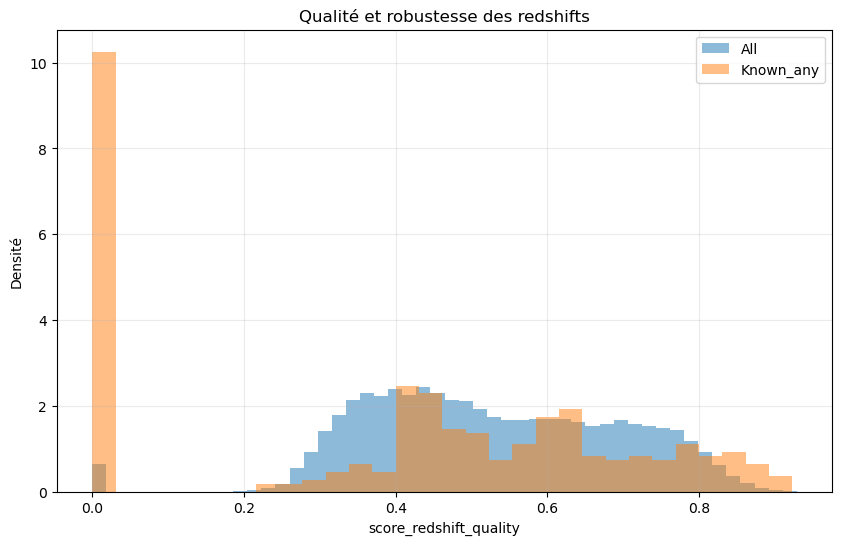

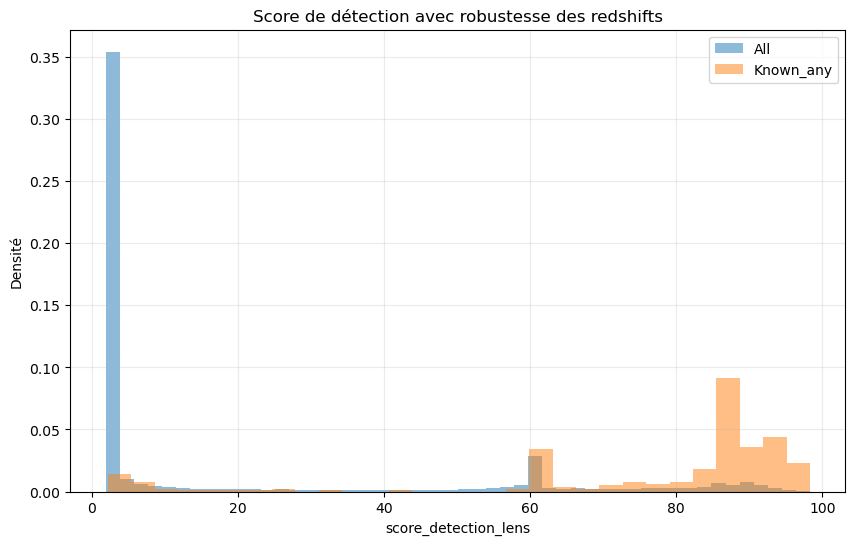


Variables principales disponibles :

final
    Toutes les paires classées.

red_component
    Une ligne par composante avec tous les indices de qualité redshift.

redshift_auxiliary_diagnostics
    Sens empirique et corrélation de ccfratio_qsoc et zscore_qsoc.

diagnostic_table
    Comparaison descriptive entre Known_any et les autres.

best_by_source_detection
    Meilleure paire pour chaque source.

strong_lens_candidates
    Candidats dépassant les seuils de détection.

strong_lens_with_reliable_delay
    Candidats forts avec un time delay également considéré fiable.



In [9]:
# =============================================================================
# CLASSEMENT COMPLET DES CANDIDATS LENTILLES
#
# Score de détection :
#   - probabilité du réseau ;
#   - compatibilité des redshifts ;
#   - qualité/robustesse des redshifts.
#
# Le time delay est conservé comme indice séparé de fiabilité de la mesure.
# Il ne sert pas directement à décider si l'objet est une lentille.
#
# Plus les scores normalisés sont proches de 1, meilleurs ils sont.
# =============================================================================

from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial import cKDTree
from scipy.stats import spearmanr
from IPython.display import display


# =============================================================================
# 1. CONFIGURATION
# =============================================================================

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"


TD_PATH = DATA_DIR / "summary_table_quasars.csv"
PROBA_PATH = DATA_DIR / "nnet_pair_predictions.csv"
REDSHIFT_PATH = DATA_DIR / "redshift_True.csv"
FULL_PATH = DATA_DIR / "BigEOL.csv"

LC_PATH = DATA_DIR / "cleaned_lightcurves.csv"
KNOWN_LC_PATH = DATA_DIR / "dgdreq2025nov21_JB.csv"


OUTPUT_ALL_PATH = (
    DATA_DIR
    / "pair_candidates_redshift_quality_ranked.csv"
)

OUTPUT_TOP_PATH = (
    DATA_DIR
    / "pair_candidates_redshift_quality_top500.csv"
)

OUTPUT_SOURCE_PATH = (
    DATA_DIR
    / "source_best_candidates_redshift_quality.csv"
)


# -----------------------------------------------------------------------------
# Poids du score de détection
# -----------------------------------------------------------------------------

DETECTION_WEIGHT_PROBA = 0.75
DETECTION_WEIGHT_REDSHIFT = 0.25

MISSING_REDSHIFT_FACTOR = 0.55
DETECTION_EPSILON = 0.01


# -----------------------------------------------------------------------------
# Paramètres du redshift
# -----------------------------------------------------------------------------

Z_ABSOLUTE_FLOOR = 0.01
Z_RELATIVE_FLOOR = 0.02

# Importance de la compatibilité et de la qualité dans score_redshift.
REDSHIFT_MATCH_WEIGHT = 0.65
REDSHIFT_QUALITY_WEIGHT = 0.35

# Corrélation minimale pour intégrer automatiquement ccfratio/zscore.
MIN_AUXILIARY_SPEARMAN = 0.05
MIN_AUXILIARY_VALID_VALUES = 100


# -----------------------------------------------------------------------------
# Paramètres du time delay
# -----------------------------------------------------------------------------

TD_COMPARE_ABSOLUTE_VALUES = False
TD_MAX_ABS_DAYS = 2000.0

TD_ABSOLUTE_TOLERANCE_DAYS = 5.0
TD_RELATIVE_TOLERANCE = 0.05
TD_MAX_TOLERANCE_DAYS = 20.0

TD_TARGET_N_METHODS = 8
TD_TARGET_N_FAMILIES = 4


# -----------------------------------------------------------------------------
# Seuils de sélection
# -----------------------------------------------------------------------------

MIN_PROBA_STRONG_LENS = 0.70
MIN_REDSHIFT_SCORE_STRONG_LENS = 0.50
MIN_DETECTION_SCORE_STRONG_LENS = 65.0

MIN_TD_RELIABILITY = 0.50
MIN_TD_FAMILIES = 3
MIN_TD_AGREEMENT = 0.60

KNOWN_RADEC_RADIUS_ARCSEC = 2.0
CSV_CHUNKSIZE = 500_000
TOP_N_TO_SAVE = 500


# =============================================================================
# 2. COLONNES
# =============================================================================

ALL_ID_COLUMNS = {
    "Source_Id",
    "Source_Id_1",
    "Source_Id_2",
    "sourceID",
    "compA",
    "compB",
    "sourceId",
    "sourceId_1",
    "source_id",
    "SourceID_2",
    "SIdComp",
    "componentId",
    "component_source_id",
    "matchedSourceIdDR4",
    "lensComponentSourceId",
}


PROBA_COLUMNS = [
    "sourceID",
    "compA",
    "compB",
    "Proba",
]


FULL_COLUMNS = [
    "sourceId",
    "SIdComp",
    "componentId",
    "raComp",
    "stdRaComp",
    "decComp",
    "stdDecComp",
    "GComp",
    "stdGComp",
    "vpuGMagComp",
    "stdVpuGMagComp",
    "minG",
    "maxG",
    "nObsComp",
    "matchedSourceIdDR4",
    "matchedDistance",
]


REDSHIFT_COLUMNS = [
    "sourceId_1",
    "SIdComp",
    "componentId",
    "component_source_id",
    "source_id",

    "redshift_qsoc",
    "redShift_qsoc_lower",
    "redShift_qsoc_upper",
    "redshift_qsoc_prob",
    "redshift_qsoc_logprob",

    "redShiftalt_qsoc",
    "redShiftalt_qsoc_lower",
    "redShiftalt_qsoc_upper",
    "redShiftalt_qsoc_prob",
    "redShiftalt_qsoc_logprob",

    "gmag_qsoc",
    "gmag_qsoc_lower",
    "gmag_qsoc_upper",

    "ccfratio_qsoc",
    "zscore_qsoc",
    "flags_qsoc",
]


LC_COLUMNS = [
    "lensComponentSourceId",
    "flux_obs_error",
]


KNOWN_LC_COLUMNS = [
    "source_id",
    "lensComponentSourceId",
]


# =============================================================================
# 3. OUTILS GÉNÉRAUX
# =============================================================================

def require_file(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(
            f"Fichier introuvable : {path}"
        )


def get_csv_columns(path):
    require_file(path)

    return (
        pd.read_csv(path, nrows=0)
        .columns
        .astype(str)
        .str.strip()
        .tolist()
    )


def existing_columns(path, requested):
    available = set(get_csv_columns(path))

    return [
        column
        for column in requested
        if column in available
    ]


def csv_dtype_map(path):
    available = set(get_csv_columns(path))

    return {
        column: "string"
        for column in ALL_ID_COLUMNS
        if column in available
    }


def read_csv_clean(path, usecols=None):
    require_file(path)

    if usecols is not None:
        usecols = existing_columns(
            path,
            usecols,
        )

    df = pd.read_csv(
        path,
        usecols=usecols,
        dtype=csv_dtype_map(path),
        low_memory=False,
    )

    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
    )

    unnamed = [
        column
        for column in df.columns
        if column.startswith("Unnamed")
    ]

    if unnamed:
        df = df.drop(columns=unnamed)

    return df


def read_optional_csv_clean(path, usecols=None):
    path = Path(path)

    if not path.exists():
        print(f"[fichier optionnel absent] {path}")
        return pd.DataFrame()

    return read_csv_clean(
        path,
        usecols=usecols,
    )


def to_id(series):
    values = (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True,
        )
    )

    valid = values.str.fullmatch(
        r"[+-]?\d+",
        na=False,
    )

    values = values.mask(~valid)

    return pd.to_numeric(
        values,
        errors="coerce",
    ).astype("Int64")


def numeric(series):
    return pd.to_numeric(
        series,
        errors="coerce",
    )


def clip01(series):
    return numeric(series).clip(
        lower=0.0,
        upper=1.0,
    )


def pair_key(component_1, component_2):
    component_1 = to_id(component_1)
    component_2 = to_id(component_2)

    pairs = pd.concat(
        [component_1, component_2],
        axis=1,
    )

    lower = (
        pairs.min(axis=1)
        .astype("Int64")
    )

    upper = (
        pairs.max(axis=1)
        .astype("Int64")
    )

    key = (
        lower.astype("string")
        + "_"
        + upper.astype("string")
    )

    return key.mask(
        component_1.isna()
        | component_2.isna()
    )


def choose_first_existing(columns, candidates):
    for candidate in candidates:
        if candidate in columns:
            return candidate

    raise ValueError(
        "Aucune colonne trouvée parmi : "
        + ", ".join(candidates)
    )


def keep_existing_unique(df, columns):
    output = []
    seen = set()

    for column in columns:
        if (
            column in df.columns
            and column not in seen
        ):
            output.append(column)
            seen.add(column)

    return output


def row_nanmean(values):
    values = np.asarray(values, dtype=float)

    valid = np.isfinite(values)
    count = valid.sum(axis=1)

    total = np.where(
        valid,
        values,
        0.0,
    ).sum(axis=1)

    output = np.full(
        len(values),
        np.nan,
        dtype=float,
    )

    np.divide(
        total,
        count,
        out=output,
        where=count > 0,
    )

    return output


def row_nanmedian(values):
    with warnings.catch_warnings():
        warnings.simplefilter(
            "ignore",
            RuntimeWarning,
        )

        return np.nanmedian(
            values,
            axis=1,
        )


def row_nanquantile(values, q):
    with warnings.catch_warnings():
        warnings.simplefilter(
            "ignore",
            RuntimeWarning,
        )

        return np.nanquantile(
            values,
            q=q,
            axis=1,
        )


def load_filtered_component_csv(
    path,
    requested_columns,
    component_id_candidates,
    needed_component_ids,
):
    require_file(path)

    available = get_csv_columns(path)

    component_column = choose_first_existing(
        available,
        component_id_candidates,
    )

    usecols = [
        column
        for column in dict.fromkeys(
            requested_columns
            + [component_column]
        )
        if column in available
    ]

    dtype = {
        column: "string"
        for column in ALL_ID_COLUMNS
        if column in available
    }

    chunks = []

    for chunk in pd.read_csv(
        path,
        usecols=usecols,
        dtype=dtype,
        chunksize=CSV_CHUNKSIZE,
        low_memory=False,
    ):
        chunk.columns = (
            chunk.columns
            .astype(str)
            .str.strip()
        )

        chunk["comp_id"] = to_id(
            chunk[component_column]
        )

        chunk = chunk.loc[
            chunk["comp_id"].isin(
                needed_component_ids
            )
        ].copy()

        if not chunk.empty:
            chunks.append(chunk)

    if not chunks:
        return (
            pd.DataFrame(
                columns=usecols + ["comp_id"]
            ),
            component_column,
        )

    return (
        pd.concat(
            chunks,
            ignore_index=True,
        ),
        component_column,
    )


# =============================================================================
# 4. SCORES EMPIRIQUES DE ROBUSTESSE
# =============================================================================

def probability_score(series):
    """
    Transforme une probabilité en score [0, 1].

    Si la colonne semble contenir des pourcentages 0-100,
    elle est automatiquement divisée par 100.
    """

    values = numeric(series).copy()
    finite = values.dropna()

    if finite.empty:
        return pd.Series(
            np.nan,
            index=series.index,
        )

    if finite.min() >= 0 and finite.max() <= 1.00001:
        return values.clip(0.0, 1.0)

    if finite.min() >= 0 and finite.max() <= 100.00001:
        return (values / 100.0).clip(0.0, 1.0)

    return percentile_score(
        values,
        higher_is_better=True,
    )


def percentile_score(
    series,
    higher_is_better=True,
):
    """
    Score empirique fondé sur le rang dans les données.

    Plus le score est proche de 1, meilleure est la valeur.
    """

    values = numeric(series)

    output = pd.Series(
        np.nan,
        index=values.index,
        dtype=float,
    )

    valid = values.notna()

    if valid.sum() == 0:
        return output

    if values.loc[valid].nunique() < 2:
        output.loc[valid] = 0.5
        return output

    output.loc[valid] = values.loc[valid].rank(
        pct=True,
        ascending=higher_is_better,
        method="average",
    )

    return output.clip(0.0, 1.0)


def weighted_quality_score(
    feature_scores,
    weights,
):
    """
    Moyenne pondérée ignorant les valeurs manquantes.

    Une pénalité légère est appliquée lorsque plusieurs indicateurs
    sont absents.
    """

    columns = list(feature_scores.keys())

    values = np.column_stack(
        [
            numeric(feature_scores[column])
            .to_numpy(float)
            for column in columns
        ]
    )

    weight_array = np.array(
        [
            weights[column]
            for column in columns
        ],
        dtype=float,
    )

    available = np.isfinite(values)

    weighted_sum = np.where(
        available,
        values * weight_array,
        0.0,
    ).sum(axis=1)

    available_weight = np.where(
        available,
        weight_array,
        0.0,
    ).sum(axis=1)

    total_weight = weight_array.sum()

    quality = np.full(
        len(values),
        np.nan,
        dtype=float,
    )

    np.divide(
        weighted_sum,
        available_weight,
        out=quality,
        where=available_weight > 0,
    )

    completeness = np.divide(
        available_weight,
        total_weight,
        out=np.zeros_like(
            available_weight
        ),
        where=total_weight > 0,
    )

    quality = quality * (
        0.80
        + 0.20 * completeness
    )

    return (
        np.clip(quality, 0.0, 1.0),
        np.clip(completeness, 0.0, 1.0),
    )


def flags_quality_score(series):
    """
    Interprète flags_qsoc comme un masque de bits.

    0 bit actif   -> score 1
    1 bit actif   -> score ~0.61
    2 bits actifs -> score ~0.37
    etc.
    """

    flags = numeric(series)

    output = pd.Series(
        np.nan,
        index=flags.index,
        dtype=float,
    )

    valid = flags.notna()

    def count_bits(value):
        try:
            return int(abs(int(value))).bit_count()
        except Exception:
            return np.nan

    bit_count = flags.loc[valid].map(
        count_bits
    )

    output.loc[valid] = np.exp(
        -0.50 * bit_count
    )

    return output.clip(
        lower=0.05,
        upper=1.0,
    )


def solution_ambiguity_score(
    selected_z,
    selected_probability,
    other_z,
    other_probability,
):
    """
    Pénalise une solution lorsque :
      - la solution concurrente a une probabilité comparable ;
      - les deux solutions sont très éloignées en redshift.

    Si les solutions primaire et alternative sont proches,
    l'ambiguïté est moins problématique.
    """

    selected_z = numeric(selected_z)
    other_z = numeric(other_z)

    selected_probability = probability_score(
        selected_probability
    )

    other_probability = probability_score(
        other_probability
    )

    selected_p = selected_probability.to_numpy(float)
    other_p = other_probability.to_numpy(float)

    selected_p_effective = np.where(
        np.isfinite(selected_p),
        selected_p,
        0.5,
    )

    other_p_effective = np.where(
        np.isfinite(other_p),
        other_p,
        0.5,
    )

    total_probability = (
        selected_p_effective
        + other_p_effective
    )

    dominance = np.divide(
        selected_p_effective,
        total_probability,
        out=np.full(
            len(selected_p),
            0.5,
        ),
        where=total_probability > 0,
    )

    selected_z_array = selected_z.to_numpy(float)
    other_z_array = other_z.to_numpy(float)

    redshift_separation = np.abs(
        selected_z_array
        - other_z_array
    )

    separation_scale = (
        0.03
        + 0.05
        * (
            1.0
            + np.abs(selected_z_array)
        )
    )

    different_mode_score = (
        1.0
        - np.exp(
            -redshift_separation
            / np.maximum(
                separation_scale,
                1e-12,
            )
        )
    )

    # S'il n'existe aucune solution alternative,
    # la solution sélectionnée n'est pas ambiguë.
    different_mode_score[
        ~np.isfinite(
            other_z_array
        )
    ] = 0.0

    ambiguity_quality = (
        1.0
        - (
            1.0 - dominance
        )
        * different_mode_score
    )

    return pd.Series(
        np.clip(
            ambiguity_quality,
            0.0,
            1.0,
        ),
        index=selected_z.index,
    )


def infer_auxiliary_feature_score(
    feature,
    baseline_quality,
    feature_name,
):
    """
    Détermine à partir des données si une grande ou une petite valeur
    de l'indicateur auxiliaire est associée à une meilleure qualité.

    Aucun label Known n'est utilisé.
    """

    x = numeric(feature)
    y = numeric(baseline_quality)

    valid = (
        x.notna()
        & y.notna()
    )

    result = {
        "feature": feature_name,
        "n_valid": int(valid.sum()),
        "spearman_rho": np.nan,
        "direction": "non_utilise",
        "active": False,
    }

    neutral = pd.Series(
        np.nan,
        index=x.index,
        dtype=float,
    )

    neutral.loc[x.notna()] = 0.5

    if (
        valid.sum()
        < MIN_AUXILIARY_VALID_VALUES
        or x.loc[valid].nunique() < 2
    ):
        return neutral, result

    rho_result = spearmanr(
        x.loc[valid],
        y.loc[valid],
        nan_policy="omit",
    )

    rho = float(
        rho_result.statistic
    )

    result["spearman_rho"] = rho

    if (
        not np.isfinite(rho)
        or abs(rho)
        < MIN_AUXILIARY_SPEARMAN
    ):
        return neutral, result

    higher_is_better = rho > 0

    result["active"] = True
    result["direction"] = (
        "plus_grand_meilleur"
        if higher_is_better
        else "plus_petit_meilleur"
    )

    score = percentile_score(
        x,
        higher_is_better=higher_is_better,
    )

    return score, result


# =============================================================================
# 5. CONSTRUCTION DE L'INDICE DE QUALITÉ REDSHIFT PAR COMPOSANTE
# =============================================================================

def add_component_redshift_quality(red_component):
    red_component = red_component.copy()

    numeric_columns = [
        "redshift_qsoc",
        "redShift_qsoc_lower",
        "redShift_qsoc_upper",
        "redshift_qsoc_prob",
        "redshift_qsoc_logprob",

        "redShiftalt_qsoc",
        "redShiftalt_qsoc_lower",
        "redShiftalt_qsoc_upper",
        "redShiftalt_qsoc_prob",
        "redShiftalt_qsoc_logprob",

        "gmag_qsoc",
        "gmag_qsoc_lower",
        "gmag_qsoc_upper",

        "ccfratio_qsoc",
        "zscore_qsoc",
        "flags_qsoc",
    ]

    for column in numeric_columns:
        if column in red_component.columns:
            red_component[column] = numeric(
                red_component[column]
            )

    def get_column(name):
        if name in red_component.columns:
            return numeric(
                red_component[name]
            )

        return pd.Series(
            np.nan,
            index=red_component.index,
            dtype=float,
        )

    primary_z = get_column(
        "redshift_qsoc"
    )

    primary_lower = get_column(
        "redShift_qsoc_lower"
    )

    primary_upper = get_column(
        "redShift_qsoc_upper"
    )

    primary_probability = get_column(
        "redshift_qsoc_prob"
    )

    primary_logprob = get_column(
        "redshift_qsoc_logprob"
    )

    alternative_z = get_column(
        "redShiftalt_qsoc"
    )

    alternative_lower = get_column(
        "redShiftalt_qsoc_lower"
    )

    alternative_upper = get_column(
        "redShiftalt_qsoc_upper"
    )

    alternative_probability = get_column(
        "redShiftalt_qsoc_prob"
    )

    alternative_logprob = get_column(
        "redShiftalt_qsoc_logprob"
    )


    # -------------------------------------------------------------------------
    # Largeurs relatives des intervalles
    # -------------------------------------------------------------------------

    primary_low = np.minimum(
        primary_lower,
        primary_upper,
    )

    primary_high = np.maximum(
        primary_lower,
        primary_upper,
    )

    alternative_low = np.minimum(
        alternative_lower,
        alternative_upper,
    )

    alternative_high = np.maximum(
        alternative_lower,
        alternative_upper,
    )

    primary_relative_width = (
        primary_high - primary_low
    ) / (
        1.0 + np.abs(primary_z)
    )

    alternative_relative_width = (
        alternative_high
        - alternative_low
    ) / (
        1.0 + np.abs(alternative_z)
    )

    red_component[
        "redshift_primary_relative_width"
    ] = primary_relative_width

    red_component[
        "redshift_alt_relative_width"
    ] = alternative_relative_width


    # -------------------------------------------------------------------------
    # Vérifie que la valeur centrale appartient à l'intervalle
    # -------------------------------------------------------------------------

    primary_interval_valid = pd.Series(
        np.nan,
        index=red_component.index,
        dtype=float,
    )

    primary_bounds_available = (
        primary_z.notna()
        & primary_low.notna()
        & primary_high.notna()
    )

    primary_interval_valid.loc[
        primary_bounds_available
    ] = np.where(
        (
            primary_z.loc[
                primary_bounds_available
            ]
            >= primary_low.loc[
                primary_bounds_available
            ]
        )
        & (
            primary_z.loc[
                primary_bounds_available
            ]
            <= primary_high.loc[
                primary_bounds_available
            ]
        ),
        1.0,
        0.25,
    )


    alternative_interval_valid = pd.Series(
        np.nan,
        index=red_component.index,
        dtype=float,
    )

    alternative_bounds_available = (
        alternative_z.notna()
        & alternative_low.notna()
        & alternative_high.notna()
    )

    alternative_interval_valid.loc[
        alternative_bounds_available
    ] = np.where(
        (
            alternative_z.loc[
                alternative_bounds_available
            ]
            >= alternative_low.loc[
                alternative_bounds_available
            ]
        )
        & (
            alternative_z.loc[
                alternative_bounds_available
            ]
            <= alternative_high.loc[
                alternative_bounds_available
            ]
        ),
        1.0,
        0.25,
    )


    # -------------------------------------------------------------------------
    # Scores principaux
    # -------------------------------------------------------------------------

    primary_probability_score = probability_score(
        primary_probability
    )

    alternative_probability_score = probability_score(
        alternative_probability
    )

    primary_logprob_score = percentile_score(
        primary_logprob,
        higher_is_better=True,
    )

    alternative_logprob_score = percentile_score(
        alternative_logprob,
        higher_is_better=True,
    )

    primary_width_score = percentile_score(
        primary_relative_width,
        higher_is_better=False,
    )

    alternative_width_score = percentile_score(
        alternative_relative_width,
        higher_is_better=False,
    )

    primary_ambiguity_score = (
        solution_ambiguity_score(
            selected_z=primary_z,
            selected_probability=primary_probability,
            other_z=alternative_z,
            other_probability=alternative_probability,
        )
    )

    alternative_ambiguity_score = (
        solution_ambiguity_score(
            selected_z=alternative_z,
            selected_probability=alternative_probability,
            other_z=primary_z,
            other_probability=primary_probability,
        )
    )


    # -------------------------------------------------------------------------
    # Baseline sans ccfratio/zscore
    #
    # Cette baseline sert uniquement à comprendre empiriquement le sens
    # des indicateurs auxiliaires.
    # -------------------------------------------------------------------------

    primary_baseline, _ = weighted_quality_score(
        feature_scores={
            "probability": primary_probability_score,
            "logprob": primary_logprob_score,
            "width": primary_width_score,
            "interval_valid": primary_interval_valid,
            "ambiguity": primary_ambiguity_score,
        },
        weights={
            "probability": 0.40,
            "logprob": 0.15,
            "width": 0.25,
            "interval_valid": 0.05,
            "ambiguity": 0.15,
        },
    )

    alternative_baseline, _ = weighted_quality_score(
        feature_scores={
            "probability": alternative_probability_score,
            "logprob": alternative_logprob_score,
            "width": alternative_width_score,
            "interval_valid": alternative_interval_valid,
            "ambiguity": alternative_ambiguity_score,
        },
        weights={
            "probability": 0.40,
            "logprob": 0.15,
            "width": 0.25,
            "interval_valid": 0.05,
            "ambiguity": 0.15,
        },
    )

    component_baseline = np.nanmax(
        np.column_stack(
            [
                primary_baseline,
                alternative_baseline,
            ]
        ),
        axis=1,
    )

    component_baseline = pd.Series(
        component_baseline,
        index=red_component.index,
    )


    # -------------------------------------------------------------------------
    # Analyse empirique de ccfratio_qsoc et zscore_qsoc
    # -------------------------------------------------------------------------

    ccfratio_score, ccfratio_diagnostic = (
        infer_auxiliary_feature_score(
            feature=get_column(
                "ccfratio_qsoc"
            ),
            baseline_quality=component_baseline,
            feature_name="ccfratio_qsoc",
        )
    )

    zscore_score, zscore_diagnostic = (
        infer_auxiliary_feature_score(
            feature=get_column(
                "zscore_qsoc"
            ),
            baseline_quality=component_baseline,
            feature_name="zscore_qsoc",
        )
    )


    # -------------------------------------------------------------------------
    # Flags
    # -------------------------------------------------------------------------

    if "flags_qsoc" in red_component.columns:
        flag_score = flags_quality_score(
            red_component[
                "flags_qsoc"
            ]
        )
    else:
        flag_score = pd.Series(
            np.nan,
            index=red_component.index,
        )


    # -------------------------------------------------------------------------
    # Incertitude photométrique QSOC
    # -------------------------------------------------------------------------

    gmag = get_column(
        "gmag_qsoc"
    )

    gmag_lower = get_column(
        "gmag_qsoc_lower"
    )

    gmag_upper = get_column(
        "gmag_qsoc_upper"
    )

    gmag_width = (
        np.maximum(
            gmag_lower,
            gmag_upper,
        )
        - np.minimum(
            gmag_lower,
            gmag_upper,
        )
    )

    gmag_relative_width = (
        gmag_width
        / (
            1.0 + np.abs(gmag)
        )
    )

    gmag_precision_score = percentile_score(
        gmag_relative_width,
        higher_is_better=False,
    )


    # -------------------------------------------------------------------------
    # Poids finaux
    # -------------------------------------------------------------------------

    ccfratio_weight = (
        0.06
        if ccfratio_diagnostic["active"]
        else 0.0
    )

    zscore_weight = (
        0.06
        if zscore_diagnostic["active"]
        else 0.0
    )

    quality_weights = {
        "probability": 0.28,
        "logprob": 0.12,
        "width": 0.18,
        "interval_valid": 0.06,
        "ambiguity": 0.18,
        "ccfratio": ccfratio_weight,
        "zscore": zscore_weight,
        "flags": 0.08,
        "gmag_precision": 0.04,
    }


    primary_quality, primary_completeness = (
        weighted_quality_score(
            feature_scores={
                "probability": primary_probability_score,
                "logprob": primary_logprob_score,
                "width": primary_width_score,
                "interval_valid": primary_interval_valid,
                "ambiguity": primary_ambiguity_score,
                "ccfratio": ccfratio_score,
                "zscore": zscore_score,
                "flags": flag_score,
                "gmag_precision": gmag_precision_score,
            },
            weights=quality_weights,
        )
    )


    alternative_quality, alternative_completeness = (
        weighted_quality_score(
            feature_scores={
                "probability": alternative_probability_score,
                "logprob": alternative_logprob_score,
                "width": alternative_width_score,
                "interval_valid": alternative_interval_valid,
                "ambiguity": alternative_ambiguity_score,
                "ccfratio": ccfratio_score,
                "zscore": zscore_score,
                "flags": flag_score,
                "gmag_precision": gmag_precision_score,
            },
            weights=quality_weights,
        )
    )


    primary_quality[
        primary_z.isna()
    ] = np.nan

    alternative_quality[
        alternative_z.isna()
    ] = np.nan


    # -------------------------------------------------------------------------
    # Colonnes de sortie
    # -------------------------------------------------------------------------

    red_component[
        "redshift_primary_probability_score"
    ] = primary_probability_score

    red_component[
        "redshift_primary_logprob_score"
    ] = primary_logprob_score

    red_component[
        "redshift_primary_width_score"
    ] = primary_width_score

    red_component[
        "redshift_primary_ambiguity_score"
    ] = primary_ambiguity_score

    red_component[
        "redshift_quality_primary"
    ] = primary_quality

    red_component[
        "redshift_quality_primary_completeness"
    ] = primary_completeness


    red_component[
        "redshift_alt_probability_score"
    ] = alternative_probability_score

    red_component[
        "redshift_alt_logprob_score"
    ] = alternative_logprob_score

    red_component[
        "redshift_alt_width_score"
    ] = alternative_width_score

    red_component[
        "redshift_alt_ambiguity_score"
    ] = alternative_ambiguity_score

    red_component[
        "redshift_quality_alt"
    ] = alternative_quality

    red_component[
        "redshift_quality_alt_completeness"
    ] = alternative_completeness


    red_component[
        "redshift_ccfratio_score"
    ] = ccfratio_score

    red_component[
        "redshift_zscore_score"
    ] = zscore_score

    red_component[
        "redshift_flags_score"
    ] = flag_score

    red_component[
        "redshift_gmag_precision_score"
    ] = gmag_precision_score


    diagnostics = pd.DataFrame(
        [
            ccfratio_diagnostic,
            zscore_diagnostic,
        ]
    )

    return red_component, diagnostics


# =============================================================================
# 6. SCORE DE COMPATIBILITÉ ET QUALITÉ DE LA PAIRE DE REDSHIFTS
# =============================================================================

def redshift_sigma(
    redshift,
    lower,
    upper,
):
    left_error = np.abs(
        redshift - lower
    )

    right_error = np.abs(
        upper - redshift
    )

    return row_nanmean(
        np.column_stack(
            [
                left_error,
                right_error,
            ]
        )
    )


def add_pair_redshift_score(df):
    df = df.copy()

    solution_specs = {
        "primary": {
            "z": "redshift_qsoc",
            "lower": "redShift_qsoc_lower",
            "upper": "redShift_qsoc_upper",
            "quality": "redshift_quality_primary",
        },
        "alt": {
            "z": "redShiftalt_qsoc",
            "lower": "redShiftalt_qsoc_lower",
            "upper": "redShiftalt_qsoc_upper",
            "quality": "redshift_quality_alt",
        },
    }

    n_rows = len(df)

    combo_names = []
    combo_scores = []
    combo_match_scores = []
    combo_quality_scores = []
    combo_differences = []
    combo_normalized_differences = []
    combo_z1 = []
    combo_z2 = []
    combo_q1 = []
    combo_q2 = []

    def get_array(base_name, suffix):
        column = f"{base_name}_{suffix}"

        if column not in df.columns:
            return np.full(
                n_rows,
                np.nan,
            )

        return numeric(
            df[column]
        ).to_numpy(float)

    for name_1, spec_1 in solution_specs.items():
        for name_2, spec_2 in solution_specs.items():

            combo_name = (
                f"{name_1}_{name_2}"
            )

            z1 = get_array(
                spec_1["z"],
                "1",
            )

            z2 = get_array(
                spec_2["z"],
                "2",
            )

            lower_1 = get_array(
                spec_1["lower"],
                "1",
            )

            upper_1 = get_array(
                spec_1["upper"],
                "1",
            )

            lower_2 = get_array(
                spec_2["lower"],
                "2",
            )

            upper_2 = get_array(
                spec_2["upper"],
                "2",
            )

            quality_1 = get_array(
                spec_1["quality"],
                "1",
            )

            quality_2 = get_array(
                spec_2["quality"],
                "2",
            )


            valid_pair = (
                np.isfinite(z1)
                & np.isfinite(z2)
            )

            difference = np.abs(
                z1 - z2
            )

            mean_z = (
                0.5
                * (
                    np.abs(z1)
                    + np.abs(z2)
                )
            )

            low_1 = np.minimum(
                lower_1,
                upper_1,
            )

            high_1 = np.maximum(
                lower_1,
                upper_1,
            )

            low_2 = np.minimum(
                lower_2,
                upper_2,
            )

            high_2 = np.maximum(
                lower_2,
                upper_2,
            )

            sigma_1 = redshift_sigma(
                z1,
                low_1,
                high_1,
            )

            sigma_2 = redshift_sigma(
                z2,
                low_2,
                high_2,
            )

            uncertainty_floor = (
                Z_ABSOLUTE_FLOOR
                + Z_RELATIVE_FLOOR
                * (
                    1.0 + mean_z
                )
            )

            total_sigma = np.sqrt(
                np.where(
                    np.isfinite(sigma_1),
                    sigma_1,
                    0.0,
                ) ** 2
                + np.where(
                    np.isfinite(sigma_2),
                    sigma_2,
                    0.0,
                ) ** 2
                + uncertainty_floor**2
            )

            normalized_difference = (
                difference
                / np.maximum(
                    total_sigma,
                    1e-12,
                )
            )

            gaussian_match = np.exp(
                -0.5
                * normalized_difference**2
            )


            valid_bounds = (
                np.isfinite(low_1)
                & np.isfinite(high_1)
                & np.isfinite(low_2)
                & np.isfinite(high_2)
            )

            intersection = np.maximum(
                0.0,
                np.minimum(
                    high_1,
                    high_2,
                )
                - np.maximum(
                    low_1,
                    low_2,
                ),
            )

            union = (
                np.maximum(
                    high_1,
                    high_2,
                )
                - np.minimum(
                    low_1,
                    low_2,
                )
            )

            interval_overlap = np.full(
                n_rows,
                np.nan,
            )

            valid_union = (
                valid_bounds
                & (union > 0)
            )

            interval_overlap[
                valid_union
            ] = (
                intersection[valid_union]
                / union[valid_union]
            )

            compatibility_score = np.where(
                np.isfinite(
                    interval_overlap
                ),
                0.80 * gaussian_match
                + 0.20 * interval_overlap,
                gaussian_match,
            )


            quality_1_effective = np.where(
                np.isfinite(quality_1),
                quality_1,
                0.35,
            )

            quality_2_effective = np.where(
                np.isfinite(quality_2),
                quality_2,
                0.35,
            )

            # Moyenne harmonique : une composante de mauvaise qualité
            # pénalise fortement la paire.
            pair_quality = np.divide(
                2.0
                * quality_1_effective
                * quality_2_effective,
                quality_1_effective
                + quality_2_effective,
                out=np.zeros(n_rows),
                where=(
                    quality_1_effective
                    + quality_2_effective
                ) > 0,
            )

            # Combinaison géométrique pondérée.
            combined_score = (
                np.power(
                    0.01
                    + 0.99
                    * compatibility_score,
                    REDSHIFT_MATCH_WEIGHT,
                )
                * np.power(
                    0.01
                    + 0.99
                    * pair_quality,
                    REDSHIFT_QUALITY_WEIGHT,
                )
            )

            combined_score[
                ~valid_pair
            ] = np.nan

            compatibility_score[
                ~valid_pair
            ] = np.nan

            pair_quality[
                ~valid_pair
            ] = np.nan

            difference[
                ~valid_pair
            ] = np.nan

            normalized_difference[
                ~valid_pair
            ] = np.nan


            df[
                f"z_diff_{combo_name}"
            ] = difference

            df[
                f"z_norm_diff_{combo_name}"
            ] = normalized_difference

            df[
                f"z_match_score_{combo_name}"
            ] = compatibility_score

            df[
                f"z_quality_score_{combo_name}"
            ] = pair_quality

            df[
                f"z_combined_score_{combo_name}"
            ] = combined_score


            combo_names.append(combo_name)
            combo_scores.append(combined_score)
            combo_match_scores.append(
                compatibility_score
            )
            combo_quality_scores.append(
                pair_quality
            )
            combo_differences.append(difference)
            combo_normalized_differences.append(
                normalized_difference
            )
            combo_z1.append(z1)
            combo_z2.append(z2)
            combo_q1.append(quality_1)
            combo_q2.append(quality_2)


    score_matrix = np.column_stack(
        combo_scores
    )

    finite_score = np.isfinite(
        score_matrix
    )

    redshift_available = finite_score.any(
        axis=1
    )

    safe_scores = np.where(
        finite_score,
        score_matrix,
        -np.inf,
    )

    best_index = np.argmax(
        safe_scores,
        axis=1,
    )

    row_index = np.arange(n_rows)

    def select_best(arrays):
        matrix = np.column_stack(arrays)

        result = matrix[
            row_index,
            best_index,
        ]

        result[
            ~redshift_available
        ] = np.nan

        return result


    best_score = select_best(
        combo_scores
    )

    best_match = select_best(
        combo_match_scores
    )

    best_quality = select_best(
        combo_quality_scores
    )

    best_difference = select_best(
        combo_differences
    )

    best_normalized_difference = (
        select_best(
            combo_normalized_differences
        )
    )

    best_z1 = select_best(combo_z1)
    best_z2 = select_best(combo_z2)
    best_q1 = select_best(combo_q1)
    best_q2 = select_best(combo_q2)

    best_combo = np.asarray(
        combo_names,
        dtype=object,
    )[best_index]

    best_combo[
        ~redshift_available
    ] = None


    df["redshift_available"] = (
        redshift_available
    )

    df["redshift_best_combo"] = (
        best_combo
    )

    df["redshift_best_z1"] = (
        best_z1
    )

    df["redshift_best_z2"] = (
        best_z2
    )

    df["redshift_best_quality_1"] = (
        best_q1
    )

    df["redshift_best_quality_2"] = (
        best_q2
    )

    df["redshift_best_abs_diff"] = (
        best_difference
    )

    df[
        "redshift_best_normalized_diff"
    ] = best_normalized_difference

    df["score_redshift_match"] = np.where(
        redshift_available,
        best_match,
        0.0,
    )

    df["score_redshift_quality"] = np.where(
        redshift_available,
        best_quality,
        0.0,
    )

    df["score_redshift"] = np.where(
        redshift_available,
        best_score,
        0.0,
    )

    df["redshift_match_0p01"] = (
        df["redshift_best_abs_diff"]
        <= 0.01
    )

    df["redshift_match_0p05"] = (
        df["redshift_best_abs_diff"]
        <= 0.05
    )

    df["redshift_match_0p10"] = (
        df["redshift_best_abs_diff"]
        <= 0.10
    )

    return df


# =============================================================================
# 7. SCORE DE FIABILITÉ DU TIME DELAY
# =============================================================================

def time_delay_family(column):
    lower = column.lower()

    if lower.startswith("td_cor_eqm"):
        return "cor_eqm"

    if lower.startswith("td_eqm"):
        return "eqm"

    if lower.startswith("td_cor"):
        return "cor"

    if lower.startswith("td_rbf"):
        return "rbf"

    if lower.startswith("td_bspl"):
        return "bspl"

    return "other"


def identify_time_delay_columns(df):
    excluded = {
        "TD_consensus",
        "TD_Q16",
        "TD_Q84",
        "TD_sigma_robust",
        "TD_max_family_residual",
        "TD_tolerance_days",
    }

    return [
        column
        for column in df.columns
        if (
            column.startswith("TD_")
            and column not in excluded
            and not column.startswith(
                "TD_family_"
            )
        )
    ]


def add_time_delay_reliability(df):
    df = df.copy()

    td_columns = identify_time_delay_columns(
        df
    )

    if not td_columns:
        df["score_td_reliability"] = 0.0
        df["score_td_reliability_100"] = 0.0
        return df

    family_columns = {}

    for column in td_columns:
        family_columns.setdefault(
            time_delay_family(column),
            [],
        ).append(column)

    all_values = (
        df[td_columns]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .to_numpy(float)
    )

    all_values[
        np.abs(all_values)
        > TD_MAX_ABS_DAYS
    ] = np.nan

    if TD_COMPARE_ABSOLUTE_VALUES:
        all_values = np.abs(all_values)

    number_methods = np.isfinite(
        all_values
    ).sum(axis=1)

    column_index = {
        column: index
        for index, column in enumerate(
            td_columns
        )
    }

    family_representatives = []
    family_internal_scores = []

    for family, columns in family_columns.items():

        indices = [
            column_index[column]
            for column in columns
        ]

        values = all_values[:, indices]

        count = np.isfinite(
            values
        ).sum(axis=1)

        representative = row_nanmedian(
            values
        )

        residuals = np.abs(
            values
            - representative[:, None]
        )

        sigma = (
            1.4826
            * row_nanmedian(residuals)
        )

        tolerance = np.minimum(
            TD_MAX_TOLERANCE_DAYS,
            TD_ABSOLUTE_TOLERANCE_DAYS
            + TD_RELATIVE_TOLERANCE
            * np.abs(representative),
        )

        internal_score = np.exp(
            -0.5
            * (
                sigma
                / np.maximum(
                    tolerance,
                    1e-12,
                )
            ) ** 2
        )

        internal_score[count == 1] = 0.5
        internal_score[count == 0] = np.nan

        df[
            f"TD_family_{family}"
        ] = representative

        df[
            f"TD_family_{family}_n"
        ] = count

        df[
            f"TD_family_{family}_sigma"
        ] = np.where(
            count >= 2,
            sigma,
            np.nan,
        )

        family_representatives.append(
            representative
        )

        family_internal_scores.append(
            internal_score
        )


    family_matrix = np.column_stack(
        family_representatives
    )

    internal_matrix = np.column_stack(
        family_internal_scores
    )

    number_families = np.isfinite(
        family_matrix
    ).sum(axis=1)

    consensus = row_nanmedian(
        family_matrix
    )

    residuals = np.abs(
        family_matrix
        - consensus[:, None]
    )

    tolerance = np.minimum(
        TD_MAX_TOLERANCE_DAYS,
        TD_ABSOLUTE_TOLERANCE_DAYS
        + TD_RELATIVE_TOLERANCE
        * np.abs(consensus),
    )

    closeness = np.exp(
        -0.5
        * (
            residuals
            / np.maximum(
                tolerance[:, None],
                1e-12,
            )
        ) ** 2
    )

    closeness[
        ~np.isfinite(family_matrix)
    ] = np.nan

    convergence = row_nanmean(
        closeness
    )

    agreeing = (
        np.isfinite(family_matrix)
        & (
            residuals
            <= tolerance[:, None]
        )
    )

    number_agreeing = agreeing.sum(
        axis=1
    )

    agreement_fraction = (
        number_agreeing
        / np.maximum(
            number_families,
            1,
        )
    )

    internal_stability = row_nanmean(
        internal_matrix
    )

    internal_stability = np.where(
        np.isfinite(internal_stability),
        internal_stability,
        0.5,
    )

    robust_sigma = (
        1.4826
        * row_nanmedian(residuals)
    )

    robust_sigma[
        number_families < 2
    ] = np.nan

    dispersion_score = np.exp(
        -0.5
        * (
            robust_sigma
            / np.maximum(
                tolerance,
                1e-12,
            )
        ) ** 2
    )

    dispersion_score = np.where(
        np.isfinite(dispersion_score),
        dispersion_score,
        0.0,
    )

    method_coverage = np.clip(
        number_methods
        / TD_TARGET_N_METHODS,
        0.0,
        1.0,
    )

    family_coverage = np.select(
        [
            number_families >= 5,
            number_families >= 4,
            number_families >= 3,
        ],
        [
            1.00,
            0.90,
            0.60,
        ],
        default=0.0,
    )

    convergence = np.where(
        np.isfinite(convergence),
        convergence,
        0.0,
    )

    reliability = (
        (
            0.45 * convergence
            + 0.25 * agreement_fraction
            + 0.15 * dispersion_score
            + 0.15 * internal_stability
        )
        * family_coverage
        * (
            0.70
            + 0.30 * method_coverage
        )
    )

    reliability[
        number_methods == 0
    ] = 0.0

    reliability = np.clip(
        reliability,
        0.0,
        1.0,
    )


    df["TD_consensus"] = consensus

    df["TD_Q16"] = row_nanquantile(
        family_matrix,
        0.16,
    )

    df["TD_Q84"] = row_nanquantile(
        family_matrix,
        0.84,
    )

    df["TD_sigma_robust"] = robust_sigma
    df["TD_tolerance_days"] = tolerance

    df["TD_n_methods"] = number_methods
    df["TD_n_families"] = number_families

    df[
        "TD_n_agreeing_families"
    ] = number_agreeing

    df[
        "TD_agreement_fraction"
    ] = agreement_fraction

    df[
        "TD_family_convergence_score"
    ] = convergence

    df[
        "TD_internal_stability_score"
    ] = internal_stability

    df[
        "TD_dispersion_score"
    ] = dispersion_score

    df["score_td_reliability"] = (
        reliability
    )

    df[
        "score_td_reliability_100"
    ] = 100.0 * reliability

    df["td_reliable"] = (
        (
            df["score_td_reliability"]
            >= MIN_TD_RELIABILITY
        )
        & (
            df["TD_n_families"]
            >= MIN_TD_FAMILIES
        )
        & (
            df["TD_agreement_fraction"]
            >= MIN_TD_AGREEMENT
        )
    )

    df["td_reliability_class"] = np.select(
        [
            (
                (reliability >= 0.75)
                & (number_families >= 4)
            ),
            (
                (reliability >= 0.50)
                & (number_families >= 3)
            ),
            (
                (reliability >= 0.25)
                & (number_families >= 3)
            ),
        ],
        [
            "A_retard_tres_fiable",
            "B_retard_fiable",
            "C_retard_incertain",
        ],
        default="D_retard_non_fiable",
    )

    return df


# =============================================================================
# 8. SCORE DE DÉTECTION
# =============================================================================

def add_detection_score(df):
    df = df.copy()

    probability = (
        clip01(df["Proba"])
        .fillna(0.0)
    )

    redshift_score = (
        clip01(
            df["score_redshift"]
        )
        .fillna(0.0)
    )

    redshift_available = (
        df["redshift_available"]
        .fillna(False)
        .astype(bool)
    )

    probability_factor = (
        DETECTION_EPSILON
        + (
            1.0 - DETECTION_EPSILON
        )
        * probability
    )

    redshift_factor = np.where(
        redshift_available,
        0.10
        + 0.90 * redshift_score,
        MISSING_REDSHIFT_FACTOR,
    )

    detection_score = (
        np.power(
            probability_factor,
            DETECTION_WEIGHT_PROBA,
        )
        * np.power(
            redshift_factor,
            DETECTION_WEIGHT_REDSHIFT,
        )
    )

    df["score_lens_prediction"] = (
        probability
    )

    df[
        "score_detection_lens_0_1"
    ] = np.clip(
        detection_score,
        0.0,
        1.0,
    )

    df["score_detection_lens"] = (
        100.0
        * df[
            "score_detection_lens_0_1"
        ]
    )

    df["strong_lens_candidate"] = (
        (
            probability
            >= MIN_PROBA_STRONG_LENS
        )
        & (
            df["score_detection_lens"]
            >= MIN_DETECTION_SCORE_STRONG_LENS
        )
        & (
            (~redshift_available)
            | (
                redshift_score
                >= MIN_REDSHIFT_SCORE_STRONG_LENS
            )
        )
    )

    if "td_reliable" in df.columns:
        df[
            "strong_lens_with_reliable_delay"
        ] = (
            df["strong_lens_candidate"]
            & df["td_reliable"]
        )

    df["candidate_detection_tier"] = (
        np.select(
            [
                (
                    (
                        df["score_detection_lens"]
                        >= 80.0
                    )
                    & (probability >= 0.80)
                    & (
                        (~redshift_available)
                        | (
                            redshift_score
                            >= 0.55
                        )
                    )
                ),
                (
                    df["score_detection_lens"]
                    >= 65.0
                ),
                (
                    df["score_detection_lens"]
                    >= 50.0
                ),
                (
                    df["score_detection_lens"]
                    >= 35.0
                ),
            ],
            [
                "A_prioritaire",
                "B_tres_interessant",
                "C_interessant",
                "D_faible",
            ],
            default="E_tres_faible",
        )
    )

    return df


# =============================================================================
# 9. OUTILS ASTROMÉTRIQUES POUR KNOWN
# =============================================================================

def angular_sep_arcsec(
    ra1,
    dec1,
    ra2,
    dec2,
):
    ra1 = np.deg2rad(
        numeric(ra1).to_numpy(float)
    )

    dec1 = np.deg2rad(
        numeric(dec1).to_numpy(float)
    )

    ra2 = np.deg2rad(
        numeric(ra2).to_numpy(float)
    )

    dec2 = np.deg2rad(
        numeric(dec2).to_numpy(float)
    )

    delta_ra = ra2 - ra1
    delta_dec = dec2 - dec1

    haversine = (
        np.sin(delta_dec / 2.0) ** 2
        + np.cos(dec1)
        * np.cos(dec2)
        * np.sin(delta_ra / 2.0) ** 2
    )

    haversine = np.clip(
        haversine,
        0.0,
        1.0,
    )

    return (
        np.rad2deg(
            2.0
            * np.arcsin(
                np.sqrt(haversine)
            )
        )
        * 3600.0
    )


def radec_to_xyz(ra, dec):
    ra = np.deg2rad(
        numeric(ra).to_numpy(float)
    )

    dec = np.deg2rad(
        numeric(dec).to_numpy(float)
    )

    return np.column_stack(
        [
            np.cos(dec) * np.cos(ra),
            np.cos(dec) * np.sin(ra),
            np.sin(dec),
        ]
    )


def nearest_known_radec(
    query_ra,
    query_dec,
    known_positions,
    radius_arcsec,
):
    output = pd.Series(
        False,
        index=query_ra.index,
    )

    if known_positions.empty:
        return output

    known_positions = (
        known_positions
        .dropna(
            subset=[
                "known_ra",
                "known_dec",
            ]
        )
    )

    if known_positions.empty:
        return output

    query = pd.DataFrame(
        {
            "ra": numeric(query_ra),
            "dec": numeric(query_dec),
        }
    )

    valid_query = query.dropna()

    if valid_query.empty:
        return output

    known_xyz = radec_to_xyz(
        known_positions["known_ra"],
        known_positions["known_dec"],
    )

    query_xyz = radec_to_xyz(
        valid_query["ra"],
        valid_query["dec"],
    )

    angle_rad = np.deg2rad(
        radius_arcsec / 3600.0
    )

    maximum_chord = (
        2.0
        * np.sin(angle_rad / 2.0)
    )

    tree = cKDTree(known_xyz)

    distance, _ = tree.query(
        query_xyz,
        k=1,
        distance_upper_bound=maximum_chord,
    )

    output.loc[
        valid_query.index
    ] = np.isfinite(distance)

    return output


# =============================================================================
# 10. CHARGEMENT DE TD
# =============================================================================

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATA_DIR     :", DATA_DIR)

TD = read_csv_clean(TD_PATH)

required_td_columns = [
    "Source_Id",
    "Source_Id_1",
    "Source_Id_2",
]

missing_td = [
    column
    for column in required_td_columns
    if column not in TD.columns
]

if missing_td:
    raise ValueError(
        f"Colonnes manquantes dans TD : {missing_td}"
    )

base = TD.copy()

base["source_id"] = to_id(
    base["Source_Id"]
)

base["comp1_id"] = to_id(
    base["Source_Id_1"]
)

base["comp2_id"] = to_id(
    base["Source_Id_2"]
)

base["pair_key"] = pair_key(
    base["comp1_id"],
    base["comp2_id"],
)

needed_component_ids = set(
    pd.concat(
        [
            base["comp1_id"],
            base["comp2_id"],
        ]
    )
    .dropna()
    .astype("int64")
    .tolist()
)

print("TD shape :", TD.shape)


# =============================================================================
# 11. LENTILLES CONNUES
# =============================================================================

KNOWN_LC = read_optional_csv_clean(
    KNOWN_LC_PATH,
    usecols=KNOWN_LC_COLUMNS,
)

known_source_ids = set()
known_component_ids = set()

if not KNOWN_LC.empty:

    if "source_id" in KNOWN_LC.columns:
        known_source_ids = set(
            to_id(
                KNOWN_LC["source_id"]
            )
            .dropna()
            .astype("int64")
            .tolist()
        )

    if (
        "lensComponentSourceId"
        in KNOWN_LC.columns
    ):
        known_component_ids = set(
            to_id(
                KNOWN_LC[
                    "lensComponentSourceId"
                ]
            )
            .dropna()
            .astype("int64")
            .tolist()
        )

needed_component_ids.update(
    known_component_ids
)

base["Known_source_id_match"] = (
    base["source_id"].isin(
        known_source_ids
    )
)

base["Known_comp1_id_match"] = (
    base["comp1_id"].isin(
        known_component_ids
    )
)

base["Known_comp2_id_match"] = (
    base["comp2_id"].isin(
        known_component_ids
    )
)


# =============================================================================
# 12. PROBABILITÉ DU RÉSEAU
# =============================================================================

PROBA = read_csv_clean(
    PROBA_PATH,
    usecols=PROBA_COLUMNS,
)

PROBA["source_id"] = to_id(
    PROBA["sourceID"]
)

PROBA["compA_id"] = to_id(
    PROBA["compA"]
)

PROBA["compB_id"] = to_id(
    PROBA["compB"]
)

PROBA["pair_key"] = pair_key(
    PROBA["compA_id"],
    PROBA["compB_id"],
)

PROBA["Proba"] = clip01(
    PROBA["Proba"]
)

proba_exact = (
    PROBA
    .groupby(
        [
            "source_id",
            "pair_key",
        ],
        as_index=False,
    )["Proba"]
    .max()
    .rename(
        columns={
            "Proba": "Proba_exact"
        }
    )
)

proba_pair = (
    PROBA
    .groupby(
        "pair_key",
        as_index=False,
    )["Proba"]
    .max()
    .rename(
        columns={
            "Proba": "Proba_pair_fallback"
        }
    )
)

base = base.merge(
    proba_exact,
    on=[
        "source_id",
        "pair_key",
    ],
    how="left",
)

base = base.merge(
    proba_pair,
    on="pair_key",
    how="left",
)

base["Proba"] = (
    base["Proba_exact"]
    .fillna(
        base[
            "Proba_pair_fallback"
        ]
    )
)


# =============================================================================
# 13. FULL / BIGEOL
# =============================================================================

Full_filtered, full_id_column = (
    load_filtered_component_csv(
        path=FULL_PATH,
        requested_columns=FULL_COLUMNS,
        component_id_candidates=[
            "SIdComp",
            "componentId",
        ],
        needed_component_ids=needed_component_ids,
    )
)

if "sourceId" in Full_filtered.columns:
    Full_filtered["sourceId"] = to_id(
        Full_filtered["sourceId"]
    )

if "nObsComp" in Full_filtered.columns:
    Full_filtered["nObsComp"] = numeric(
        Full_filtered["nObsComp"]
    )

    Full_component = (
        Full_filtered
        .sort_values(
            [
                "comp_id",
                "nObsComp",
            ],
            ascending=[
                True,
                False,
            ],
        )
        .drop_duplicates("comp_id")
    )

else:
    Full_component = (
        Full_filtered
        .drop_duplicates("comp_id")
    )

full_1 = (
    Full_component
    .add_suffix("_1")
    .rename(
        columns={
            "comp_id_1": "comp1_id"
        }
    )
)

full_2 = (
    Full_component
    .add_suffix("_2")
    .rename(
        columns={
            "comp_id_2": "comp2_id"
        }
    )
)

base = base.merge(
    full_1,
    on="comp1_id",
    how="left",
)

base = base.merge(
    full_2,
    on="comp2_id",
    how="left",
)

if {
    "raComp_1",
    "decComp_1",
    "raComp_2",
    "decComp_2",
}.issubset(base.columns):

    base["separation_arcsec"] = (
        angular_sep_arcsec(
            base["raComp_1"],
            base["decComp_1"],
            base["raComp_2"],
            base["decComp_2"],
        )
    )

else:
    base["separation_arcsec"] = np.nan


# =============================================================================
# 14. KNOWN PAR POSITION
# =============================================================================

known_positions = pd.DataFrame()

if known_component_ids:

    known_positions = (
        Full_component.loc[
            Full_component[
                "comp_id"
            ].isin(
                known_component_ids
            )
        ]
        .rename(
            columns={
                "raComp": "known_ra",
                "decComp": "known_dec",
            }
        )
    )

if {
    "raComp_1",
    "decComp_1",
}.issubset(base.columns):

    base["Known_radec_match_1"] = (
        nearest_known_radec(
            base["raComp_1"],
            base["decComp_1"],
            known_positions,
            KNOWN_RADEC_RADIUS_ARCSEC,
        )
    )

else:
    base["Known_radec_match_1"] = False


if {
    "raComp_2",
    "decComp_2",
}.issubset(base.columns):

    base["Known_radec_match_2"] = (
        nearest_known_radec(
            base["raComp_2"],
            base["decComp_2"],
            known_positions,
            KNOWN_RADEC_RADIUS_ARCSEC,
        )
    )

else:
    base["Known_radec_match_2"] = False


base["Known_any"] = (
    base["Known_source_id_match"]
    | base["Known_comp1_id_match"]
    | base["Known_comp2_id_match"]
    | base["Known_radec_match_1"]
    | base["Known_radec_match_2"]
)

base["Known"] = (
    base["Known_source_id_match"]
    | (
        base["Known_comp1_id_match"]
        & base["Known_comp2_id_match"]
    )
    | (
        base["Known_radec_match_1"]
        & base["Known_radec_match_2"]
    )
)


# =============================================================================
# 15. REDSHIFT ET INDICES DE ROBUSTESSE
# =============================================================================

REDSHIFT = read_csv_clean(
    REDSHIFT_PATH,
    usecols=REDSHIFT_COLUMNS,
)

redshift_id_column = choose_first_existing(
    REDSHIFT.columns,
    [
        "component_source_id",
        "SIdComp",
        "componentId",
    ],
)

REDSHIFT["comp_id"] = to_id(
    REDSHIFT[
        redshift_id_column
    ]
)

REDSHIFT = REDSHIFT.loc[
    REDSHIFT["comp_id"].isin(
        needed_component_ids
    )
].copy()


for column in REDSHIFT_COLUMNS:
    if (
        column in REDSHIFT.columns
        and column not in ALL_ID_COLUMNS
    ):
        REDSHIFT[column] = numeric(
            REDSHIFT[column]
        )


primary_probability = (
    probability_score(
        REDSHIFT[
            "redshift_qsoc_prob"
        ]
    )
    if "redshift_qsoc_prob"
    in REDSHIFT.columns
    else pd.Series(
        np.nan,
        index=REDSHIFT.index,
    )
)

alternative_probability = (
    probability_score(
        REDSHIFT[
            "redShiftalt_qsoc_prob"
        ]
    )
    if "redShiftalt_qsoc_prob"
    in REDSHIFT.columns
    else pd.Series(
        np.nan,
        index=REDSHIFT.index,
    )
)

REDSHIFT[
    "redshift_row_reliability"
] = pd.concat(
    [
        primary_probability,
        alternative_probability,
    ],
    axis=1,
).max(axis=1)


# Une ligne par composante.
red_component = (
    REDSHIFT
    .sort_values(
        [
            "comp_id",
            "redshift_row_reliability",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .drop_duplicates(
        "comp_id"
    )
    .copy()
)


# Calcule les indices de qualité sur les distributions réelles.
(
    red_component,
    redshift_auxiliary_diagnostics,
) = add_component_redshift_quality(
    red_component
)


print(
    "\n"
    + "=" * 100
)

print(
    "ANALYSE EMPIRIQUE DE CCFRATIO ET ZSCORE"
)

print(
    "=" * 100
)

display(
    redshift_auxiliary_diagnostics
)


redshift_distribution_columns = [
    "redshift_qsoc_prob",
    "redshift_qsoc_logprob",
    "redshift_primary_relative_width",

    "redShiftalt_qsoc_prob",
    "redShiftalt_qsoc_logprob",
    "redshift_alt_relative_width",

    "ccfratio_qsoc",
    "zscore_qsoc",
    "flags_qsoc",

    "redshift_quality_primary",
    "redshift_quality_alt",
]

redshift_distribution_columns = [
    column
    for column in redshift_distribution_columns
    if column in red_component.columns
]

print(
    "\n"
    + "=" * 100
)

print(
    "DISTRIBUTIONS DES INDICES DE ROBUSTESSE"
)

print(
    "=" * 100
)

display(
    red_component[
        redshift_distribution_columns
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .T
)


red_1 = (
    red_component
    .add_suffix("_1")
    .rename(
        columns={
            "comp_id_1": "comp1_id"
        }
    )
)

red_2 = (
    red_component
    .add_suffix("_2")
    .rename(
        columns={
            "comp_id_2": "comp2_id"
        }
    )
)

base = base.merge(
    red_1,
    on="comp1_id",
    how="left",
)

base = base.merge(
    red_2,
    on="comp2_id",
    how="left",
)


# =============================================================================
# 16. CALCUL DES SCORES
# =============================================================================

base = add_pair_redshift_score(base)
base = add_time_delay_reliability(base)
base = add_detection_score(base)


# =============================================================================
# 17. CLASSEMENT
# =============================================================================

base = (
    base
    .sort_values(
        [
            "score_detection_lens",
            "score_redshift",
            "score_redshift_quality",
            "score_td_reliability",
            "Proba",
        ],
        ascending=[
            False,
            False,
            False,
            False,
            False,
        ],
        na_position="last",
    )
    .reset_index(drop=True)
)

base["global_rank_detection"] = np.arange(
    1,
    len(base) + 1,
)

base["rank_within_source"] = (
    base
    .groupby(
        "source_id",
        dropna=False,
    )["score_detection_lens"]
    .rank(
        ascending=False,
        method="first",
    )
    .astype("Int64")
)


# =============================================================================
# 18. TABLES FINALES
# =============================================================================

first_columns = [
    "global_rank_detection",
    "rank_within_source",

    "candidate_detection_tier",
    "strong_lens_candidate",
    "strong_lens_with_reliable_delay",

    "score_detection_lens",
    "score_detection_lens_0_1",
    "score_lens_prediction",

    "score_redshift",
    "score_redshift_match",
    "score_redshift_quality",

    "score_td_reliability",
    "score_td_reliability_100",
    "td_reliable",
    "td_reliability_class",

    "source_id",
    "comp1_id",
    "comp2_id",
    "pair_key",

    "Proba",

    "redshift_available",
    "redshift_best_combo",
    "redshift_best_z1",
    "redshift_best_z2",

    "redshift_best_quality_1",
    "redshift_best_quality_2",

    "redshift_best_abs_diff",
    "redshift_best_normalized_diff",

    "TD_consensus",
    "TD_Q16",
    "TD_Q84",
    "TD_sigma_robust",

    "TD_n_methods",
    "TD_n_families",
    "TD_n_agreeing_families",
    "TD_agreement_fraction",

    "separation_arcsec",

    "Known",
    "Known_any",
]

ordered_columns = keep_existing_unique(
    base,
    first_columns,
)

remaining_columns = [
    column
    for column in base.columns
    if column not in ordered_columns
]

final = base[
    ordered_columns
    + remaining_columns
].copy()


best_by_source_detection = (
    final
    .drop_duplicates(
        "source_id",
        keep="first",
    )
    .reset_index(drop=True)
)

best_by_source_detection[
    "source_rank_detection"
] = np.arange(
    1,
    len(best_by_source_detection) + 1,
)


strong_lens_candidates = (
    final.loc[
        final[
            "strong_lens_candidate"
        ].fillna(False)
    ]
    .copy()
    .reset_index(drop=True)
)


strong_lens_with_reliable_delay = (
    final.loc[
        final[
            "strong_lens_with_reliable_delay"
        ].fillna(False)
    ]
    .copy()
    .reset_index(drop=True)
)


# =============================================================================
# 19. SAUVEGARDE
# =============================================================================

OUTPUT_ALL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

final.to_csv(
    OUTPUT_ALL_PATH,
    index=False,
)

final.head(
    TOP_N_TO_SAVE
).to_csv(
    OUTPUT_TOP_PATH,
    index=False,
)

best_by_source_detection.to_csv(
    OUTPUT_SOURCE_PATH,
    index=False,
)


# =============================================================================
# 20. DIAGNOSTICS ET AFFICHAGE
# =============================================================================

print(
    "\n"
    + "=" * 100
)

print("RÉSULTATS")

print("=" * 100)

print("Shape finale :", final.shape)

print(
    "Paires avec redshift :",
    int(
        final[
            "redshift_available"
        ].sum()
    ),
)

print(
    "Candidats lentilles forts :",
    len(strong_lens_candidates),
)

print(
    "Candidats forts avec TD fiable :",
    len(
        strong_lens_with_reliable_delay
    ),
)

print("\nFichier complet :", OUTPUT_ALL_PATH)
print("Top 500 :", OUTPUT_TOP_PATH)
print("Meilleure paire/source :", OUTPUT_SOURCE_PATH)


display_columns = keep_existing_unique(
    final,
    [
        "global_rank_detection",

        "source_id",
        "comp1_id",
        "comp2_id",

        "score_detection_lens",
        "Proba",

        "score_redshift",
        "score_redshift_match",
        "score_redshift_quality",

        "redshift_best_combo",
        "redshift_best_z1",
        "redshift_best_z2",

        "redshift_best_quality_1",
        "redshift_best_quality_2",

        "redshift_best_abs_diff",
        "redshift_best_normalized_diff",

        "score_td_reliability",
        "TD_consensus",
        "TD_sigma_robust",

        "candidate_detection_tier",
        "strong_lens_candidate",

        "Known",
        "Known_any",
    ],
)


print(
    "\n"
    + "=" * 100
)

print("100 MEILLEURS CANDIDATS")

print("=" * 100)

display(
    final[
        display_columns
    ].head(100)
)


# =============================================================================
# 21. COMPARAISON DES SCORES AVEC KNOWN_ANY
#
# Known_any n'a pas servi à construire les scores.
# Les non-Known ne sont pas nécessairement de vrais négatifs.
# =============================================================================

diagnostic_scores = [
    "Proba",
    "score_redshift_match",
    "score_redshift_quality",
    "score_redshift",
    "score_detection_lens",
    "score_td_reliability",
]

diagnostic_rows = []

if "Known_any" in final.columns:

    known_mask = (
        final["Known_any"]
        .fillna(False)
        .astype(bool)
    )

    for column in diagnostic_scores:

        values = numeric(
            final[column]
        )

        known_values = values[
            known_mask
        ].dropna()

        other_values = values[
            ~known_mask
        ].dropna()

        diagnostic_rows.append(
            {
                "score": column,

                "known_count": len(
                    known_values
                ),

                "other_count": len(
                    other_values
                ),

                "known_mean": (
                    known_values.mean()
                ),

                "other_mean": (
                    other_values.mean()
                ),

                "known_median": (
                    known_values.median()
                ),

                "other_median": (
                    other_values.median()
                ),

                "median_difference": (
                    known_values.median()
                    - other_values.median()
                ),
            }
        )


diagnostic_table = pd.DataFrame(
    diagnostic_rows
)

print(
    "\n"
    + "=" * 100
)

print("DIAGNOSTIC DES SOUS-SCORES")

print("=" * 100)

display(
    diagnostic_table.sort_values(
        "median_difference",
        ascending=False,
    )
)


# =============================================================================
# 22. GRAPHIQUES
# =============================================================================

plt.figure(figsize=(10, 6))

plt.hist(
    final[
        "score_redshift_quality"
    ].dropna(),
    bins=50,
    density=True,
    alpha=0.5,
    label="All",
)

known_redshift_quality = final.loc[
    final["Known_any"].fillna(False),
    "score_redshift_quality",
].dropna()

if not known_redshift_quality.empty:
    plt.hist(
        known_redshift_quality,
        bins=30,
        density=True,
        alpha=0.5,
        label="Known_any",
    )

plt.xlabel("score_redshift_quality")
plt.ylabel("Densité")
plt.title("Qualité et robustesse des redshifts")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


plt.figure(figsize=(10, 6))

plt.hist(
    final[
        "score_detection_lens"
    ].dropna(),
    bins=50,
    density=True,
    alpha=0.5,
    label="All",
)

known_detection = final.loc[
    final["Known_any"].fillna(False),
    "score_detection_lens",
].dropna()

if not known_detection.empty:
    plt.hist(
        known_detection,
        bins=30,
        density=True,
        alpha=0.5,
        label="Known_any",
    )

plt.xlabel("score_detection_lens")
plt.ylabel("Densité")
plt.title(
    "Score de détection avec robustesse des redshifts"
)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


print(
    "\nVariables principales disponibles :"
)

print(
    """
final
    Toutes les paires classées.

red_component
    Une ligne par composante avec tous les indices de qualité redshift.

redshift_auxiliary_diagnostics
    Sens empirique et corrélation de ccfratio_qsoc et zscore_qsoc.

diagnostic_table
    Comparaison descriptive entre Known_any et les autres.

best_by_source_detection
    Meilleure paire pour chaque source.

strong_lens_candidates
    Candidats dépassant les seuils de détection.

strong_lens_with_reliable_delay
    Candidats forts avec un time delay également considéré fiable.
"""
)